# Housing Prices Dataset Analysis

Дата: 09.06.2025
Автор: Лизун Артемий

## Изучение поставленной задачи
1. *Актуальность и значимость:* Рынок недвижимости играет важную роль в экономике, и понимание факторов, влияющих на стоимость жилья, имеет критическое значение для покупателей, продавцов и инвесторов. Каждый год миллионы людей принимают решения о покупке или продаже недвижимости, и знание факторов, влияющих на цену домов, может существенно повлиять на их выбор.
2. *Выявленные проблемы:* Существующие данные показывают, что стоимость жилья может значительно варьироваться в зависимости от множества факторов, таких как площадь, количество спален и ванных комнат, расположение и наличие удобств. Необходимость в более глубоком анализе этих факторов подчеркивается высокими колебаниями цен на рынке.
3. *Цель исследования:* Выявить факторы, оказывающие наибольшее влияние на стоимость домов. Изучение этих данных поможет как покупателем, так и продавцам.

## Подготовка к анализу 
Для начала импортируем необходимые библиотеки и загрузим наш набор данных.

In [58]:
import pandas as pd        
import numpy as np       
import matplotlib.pyplot as plt  
import seaborn as sns       
from pandas.plotting import parallel_coordinates # Библиотека для диаграммы параллельных координат
import statsmodels.api as sm # Бибилиотека для оценки статистических моделей, использовалась для диаграммы отношения шансов
from matplotlib.patches import Circle, Ellipse, Arc, Polygon

data = pd.read_csv('Housing.csv')

## Очистка, предварительная обработка и первичный анализ данных
Перед началом анализа необходимо убедиться, что данные находятся в надлежащем состоянии. Необходимо проверить наличие пропусков или дубликатов, если таковые имеются, то удалить из базы данных. Также требуется откорректировать типы данных, чтобы не было проблем с визуальным анализом в будущем. 

In [59]:
print('Первые 5 строк датасета.')
data.head()

Первые 5 строк датасета.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [60]:
print('Дубликатов в заглавном ряду нет. Названия столбцов в snake_case')
data.loc[data.duplicated()]

Дубликатов в заглавном ряду нет. Названия столбцов в snake_case


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus


In [61]:
print('Сводная статистика по датасету:')
data.describe()

Сводная статистика по датасету:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [62]:
print('Основная информация по датасету:')
data.info()
print('Пропущенных значений среди всех столбцов:', data.isnull().sum().sum(),'— очистка и обработка не требуются.')

Основная информация по датасету:
<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB
Пропущенных значений среди всех столбцов: 0 — очистка и обработка не требуются.


Так как многие данные имеют тип object (yes; no) для удобства визуального анализ превратим их в int (1;0)

In [63]:
data['mainroad'] = data['mainroad'].map({'yes': 1, 'no': 0})
data['guestroom'] = data['guestroom'].map({'yes': 1, 'no': 0})
data['basement'] = data['basement'].map({'yes': 1, 'no': 0})
data['hotwaterheating'] = data['hotwaterheating'].map({'yes': 1, 'no': 0})
data['airconditioning'] = data['airconditioning'].map({'yes': 1, 'no': 0})
data['prefarea'] = data['prefarea'].map({'yes': 1, 'no': 0})
data['furnishingstatus'] = data['furnishingstatus'].map({'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2})

In [64]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    int64
 6   guestroom         545 non-null    int64
 7   basement          545 non-null    int64
 8   hotwaterheating   545 non-null    int64
 9   airconditioning   545 non-null    int64
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    int64
 12  furnishingstatus  545 non-null    int64
dtypes: int64(13)
memory usage: 55.5 KB


Отлично. Все колонки теперь int64

# Визуальный анализ данных
В этом разделе мы исследуем данные, используя визуальный анализ. Основная цель визуального анализа — облегчить понимание информации и выявить важные взаимосвязи между переменными. В этом нам помогут графики, диаграммы, тепловые карты, сравнения и другие графические инструменты РАД. 

*Диаграмма размаха, гистограмма, столбчатая диаграмма; тепловая карта; диаграмма Парето; диаграмма рассеяния; многовариантная диаграмма; стебле-листовой график; параллельные координаты; отношение шансов; визуализация на основе глифов, например, лиц Чернова.*
## Диаграмма размаха
Диаграмма размаха, также известная как боксплот, является мощным инструментом для визуализации распределения числовых данных. Она показывает медиану, квартильные значения и выбросы в наборе данных, что позволяет быстро оценить его вариативность и наличие аномалий.

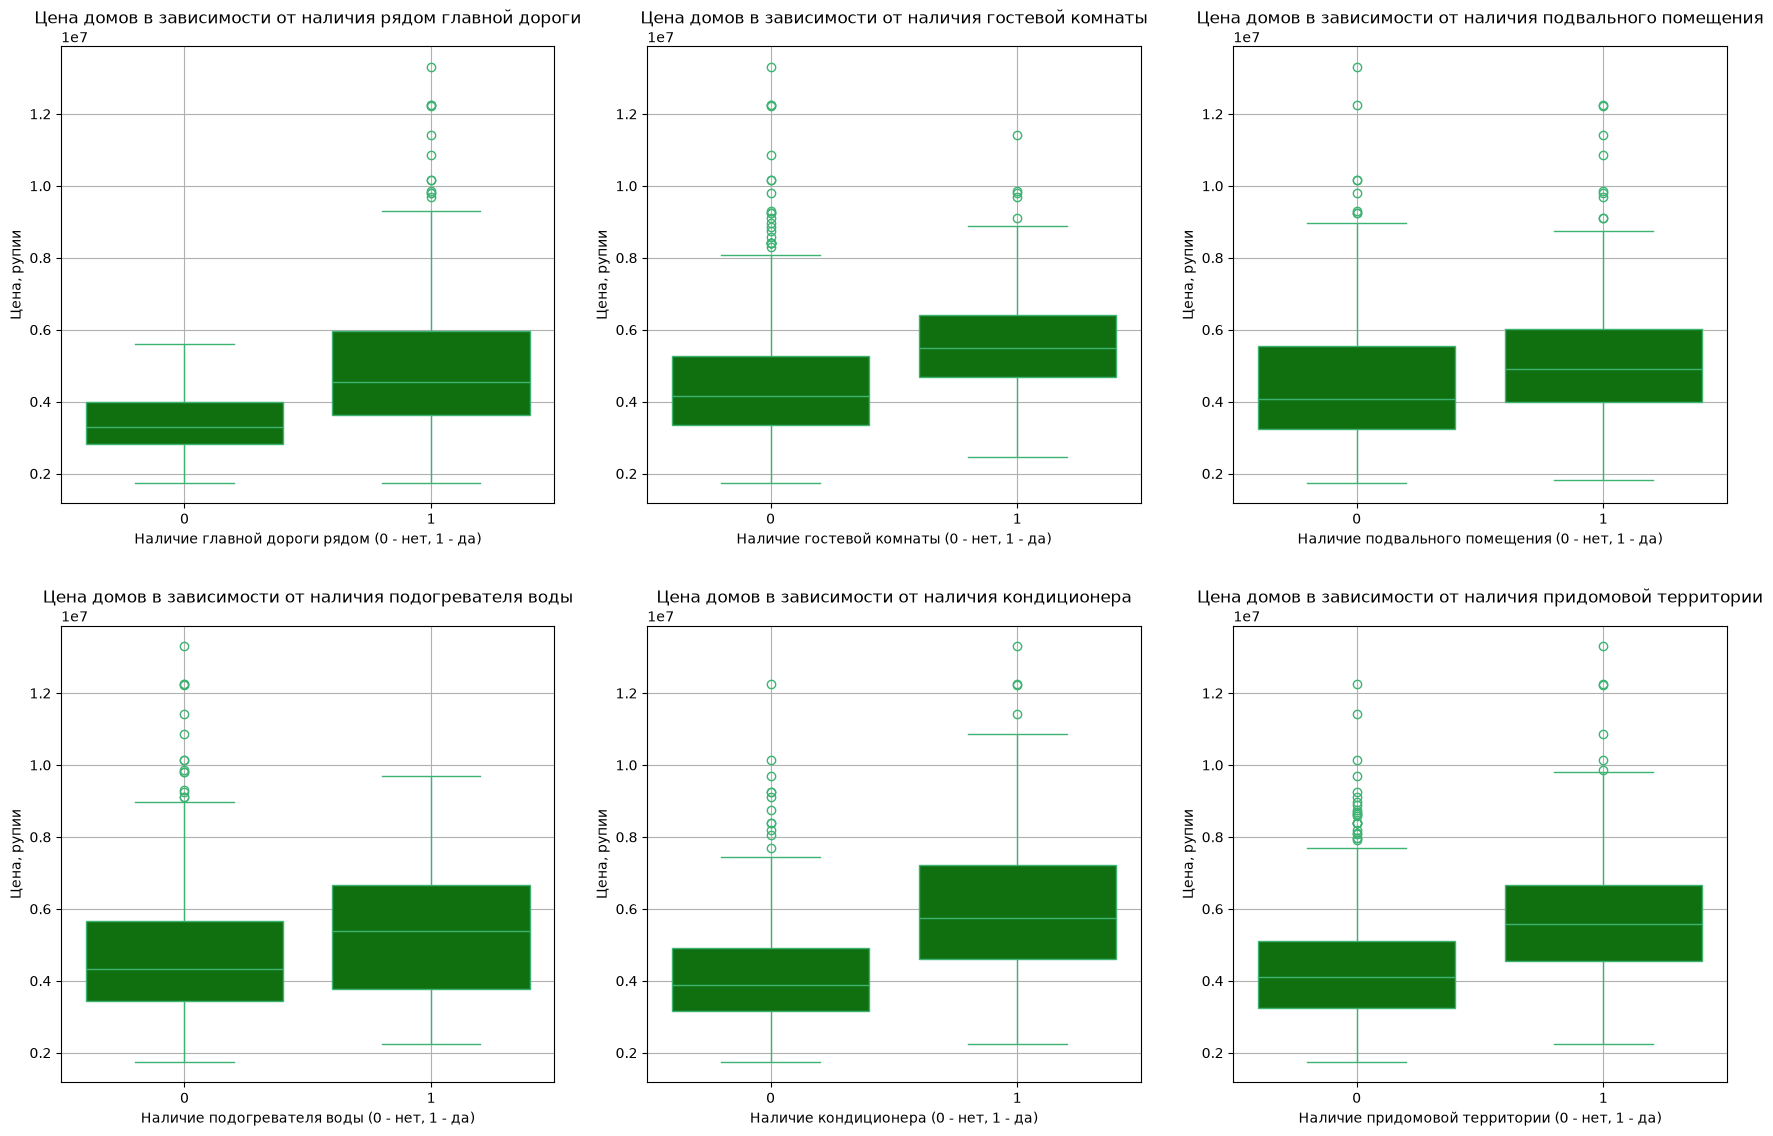

In [65]:
plt.figure(figsize=(18, 12))

plt.subplot(2,3,1)
sns.boxplot(x='mainroad', y='price', data=data, legend=False, linecolor='mediumseagreen', color ='green')
plt.title('Цена домов в зависимости от наличия рядом главной дороги')
plt.xlabel('Наличие главной дороги рядом (0 - нет, 1 - да)')
plt.ylabel('Цена, рупии')
plt.grid()

plt.subplot(2,3,2)
sns.boxplot(x='guestroom', y='price', data=data, legend=False, linecolor='mediumseagreen', color ='green')
plt.title('Цена домов в зависимости от наличия гостевой комнаты')
plt.xlabel('Наличие гостевой комнаты (0 - нет, 1 - да)')
plt.ylabel('Цена, рупии')
plt.grid()

plt.subplot(2,3,3)
sns.boxplot(x='basement', y='price', data=data, legend=False, linecolor='mediumseagreen', color ='green')
plt.title('Цена домов в зависимости от наличия подвального помещения')
plt.xlabel('Наличие подвального помещения (0 - нет, 1 - да)')
plt.ylabel('Цена, рупии')
plt.grid()

plt.subplot(2,3,4)
sns.boxplot(x='hotwaterheating', y='price', data=data, legend=False, linecolor='mediumseagreen', color ='green')
plt.title('Цена домов в зависимости от наличия подогревателя воды')
plt.xlabel('Наличие подогревателя воды (0 - нет, 1 - да)')
plt.ylabel('Цена, рупии')
plt.grid()

plt.subplot(2,3,5)
sns.boxplot(x='airconditioning', y='price', data=data, legend=False, linecolor='mediumseagreen', color ='green')
plt.title('Цена домов в зависимости от наличия кондиционера')
plt.xlabel('Наличие кондиционера (0 - нет, 1 - да)')
plt.ylabel('Цена, рупии')
plt.grid()

plt.subplot(2,3,6)
sns.boxplot(x='prefarea', y='price', data=data, legend=False, linecolor='mediumseagreen', color ='green')
plt.title('Цена домов в зависимости от наличия придомовой территории')
plt.xlabel('Наличие придомовой территории (0 - нет, 1 - да)')
plt.ylabel('Цена, рупии')
plt.grid()

plt.tight_layout(pad=3.0)
plt.show()

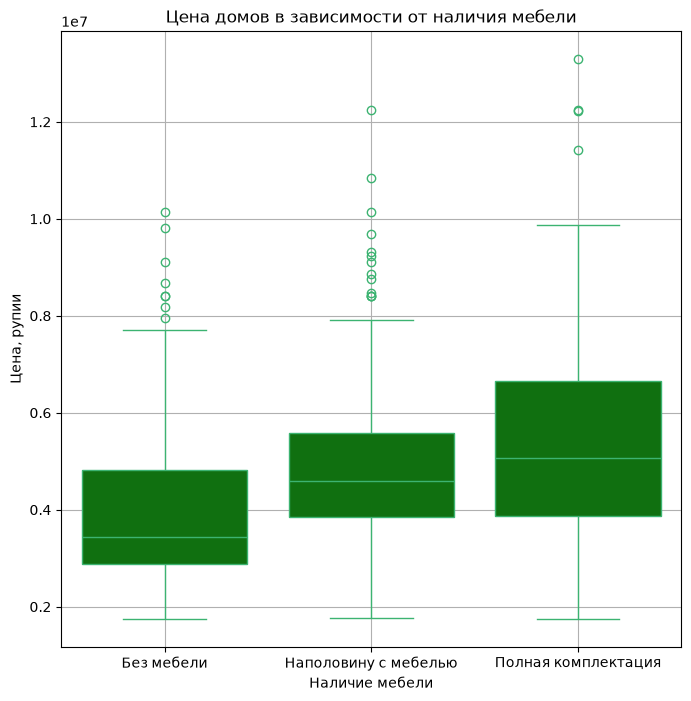

In [66]:
plt.figure(figsize=(8, 8))
sns.boxplot(x='furnishingstatus', y='price', data=data, linecolor='mediumseagreen', color='green')
plt.title('Цена домов в зависимости от наличия мебели')
plt.xlabel('Наличие мебели')
plt.ylabel('Цена, рупии')

plt.xticks(ticks=[0, 1, 2], labels=['Без мебели', 'Наполовину с мебелью', 'Полная комплектация'])

plt.grid()
plt.show()

## Столбчатая диаграмма
Столбчатая диаграмма — это графическое представление данных, которое используется для сравнения величин различных категорий. Она состоит из прямоугольных столбцов, высота которых соответствует количественному значению, которое они представляют.

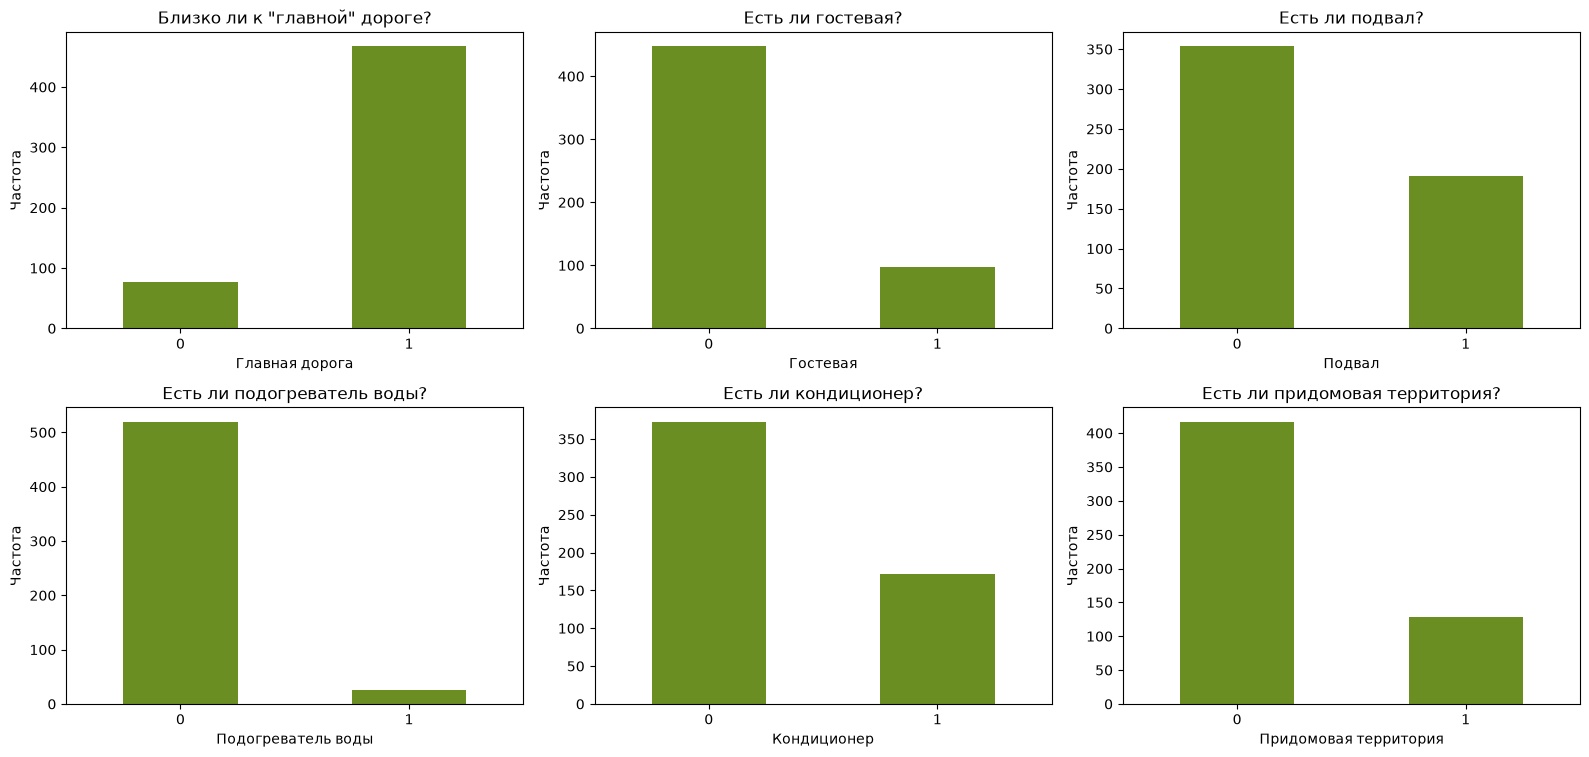

In [67]:
plt.figure(figsize=(16, 11))

plt.subplot(3,3,1)
plt1 = data['mainroad'].value_counts().sort_index(ascending=True).plot(kind='bar', color='olivedrab')
plt.title('Близко ли к "главной" дороге?')
plt1.set(xlabel = 'Главная дорога', ylabel='Частота')
plt.xticks(rotation=0)  

plt.subplot(3,3,2)
plt1 = data['guestroom'].value_counts().plot(kind='bar', color='olivedrab')
plt.title('Есть ли гостевая?')
plt1.set(xlabel = 'Гостевая', ylabel='Частота')
plt.xticks(rotation=0)  

plt.subplot(3,3,3)
plt1 = data['basement'].value_counts().plot(kind='bar', color='olivedrab')
plt.title('Есть ли подвал?')
plt1.set(xlabel = 'Подвал', ylabel='Частота')
plt.xticks(rotation=0)  

plt.subplot(3, 3, 4)
plt1 = data['hotwaterheating'].value_counts().plot(kind='bar', color='olivedrab')
plt.title('Есть ли подогреватель воды?')
plt1.set(xlabel='Подогреватель воды', ylabel='Частота')
plt.xticks(rotation=0)  

plt.subplot(3, 3, 5)
plt1 = data['airconditioning'].value_counts().plot(kind='bar', color='olivedrab')
plt.title('Есть ли кондиционер?')
plt1.set(xlabel='Кондиционер', ylabel='Частота')
plt.xticks(rotation=0)  

plt.subplot(3, 3, 6)
plt1 = data['prefarea'].value_counts().plot(kind='bar', color='olivedrab')
plt.title('Есть ли придомовая территория?')
plt1.set(xlabel='Придомовая территория', ylabel='Частота')
plt.xticks(rotation=0)  

plt.tight_layout()
plt.show()

## Гистограмма
Гистограмма — это графическое представление распределения числовых данных, которое используется для отображения частоты значений в различных интервалах. Она состоит из прямоугольных столбцов, где высота каждого столбца соответствует количеству наблюдений, попавших в заданный интервал. 

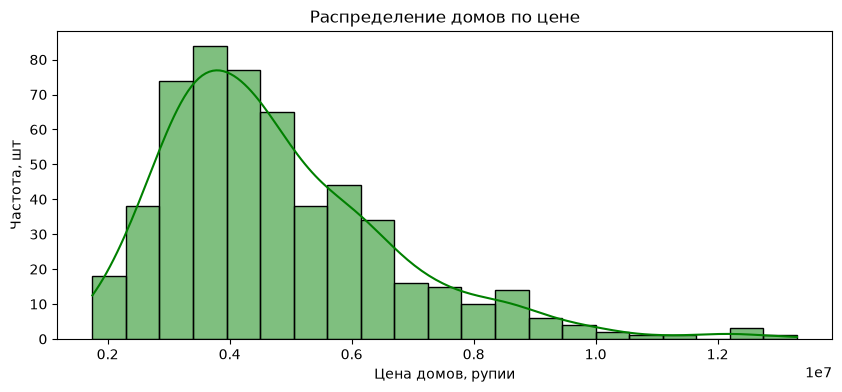

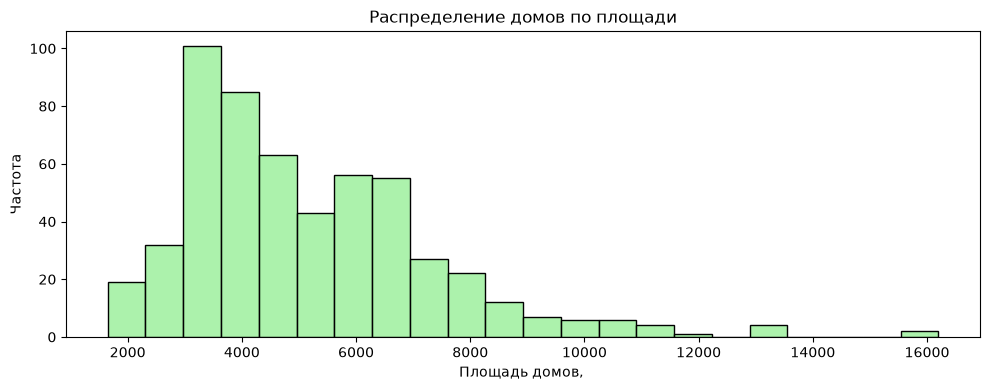

In [68]:
plt.figure(figsize=(10,4))
plt.title('Распределение домов по цене')
plt.xlabel('Цена домов, рупии')
plt.ylabel('Частота, шт')
sns.histplot(data.price,  color='green', kde = True)

plt.figure(figsize=(10,4))
plt.title('Распределение домов по площади')
plt.xlabel('Площадь домов, ')
plt.ylabel('Частота')
sns.histplot(data.area,  color='lightgreen')
plt.tight_layout()
plt.show()

Гистограмма цены:
Сильно скошено вправо (длинный правый хвост);
Распределение соответствует типичному для рынка недвижимости: большинство объектов — бюджетные/средние, редкие — премиум.

Гистограмма площади:
Также скошена вправо;
Площадь распределена чуть более умеренно, хотя выбросы справа требуют проверки (возможно элитная недвижимость).

## Тепловая карта
Тепловая карта — это графическое представление данных, в котором значения отображаются с помощью цветовых градиентов. Она Позволяет быстро увидеть, как различные переменные связаны друг с другом.

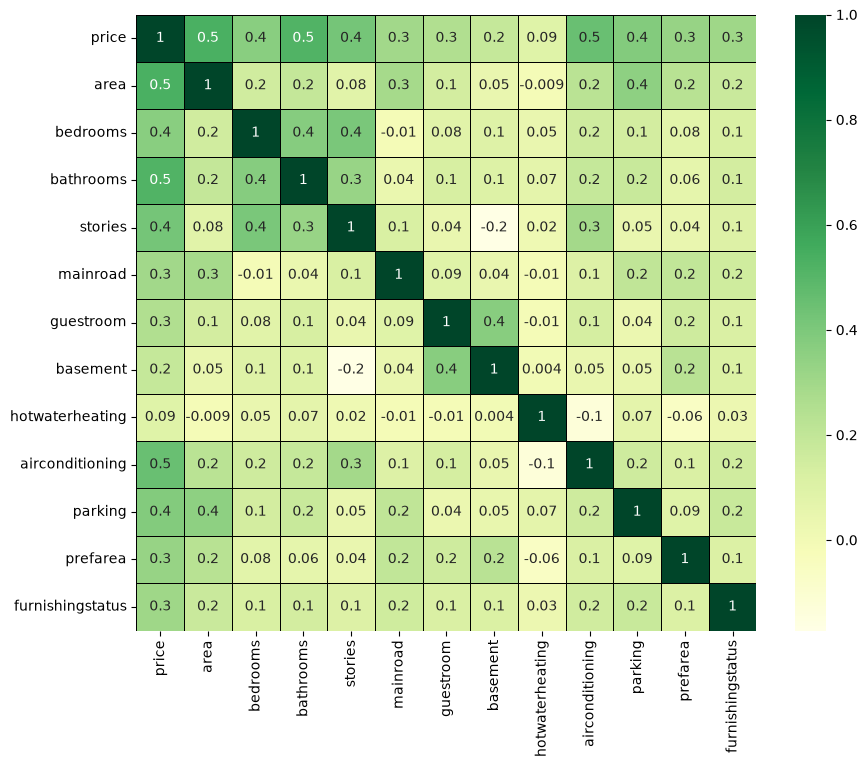

In [69]:
plt.figure(figsize=(10, 8))  
sns.heatmap(data.corr(), annot = True, fmt='.1g', cmap= 'YlGn', linewidths=0.5, linecolor='black')
plt.show()

## Диаграмма Парето
Диаграмма Парето — это вид графика, который сочетает в себе столбчатую диаграмму и линию кумулятивной частоты. Эта диаграмма используется для визуализации и анализа данных, позволяя выявить наиболее значимые факторы, влияющие на определённый процесс или проблему. На графике также есть линия (кумулятивная), показывающая общую долю, которую составляют категории. Это помогает увидеть, как небольшое количество причин может вызывать большую часть проблем.

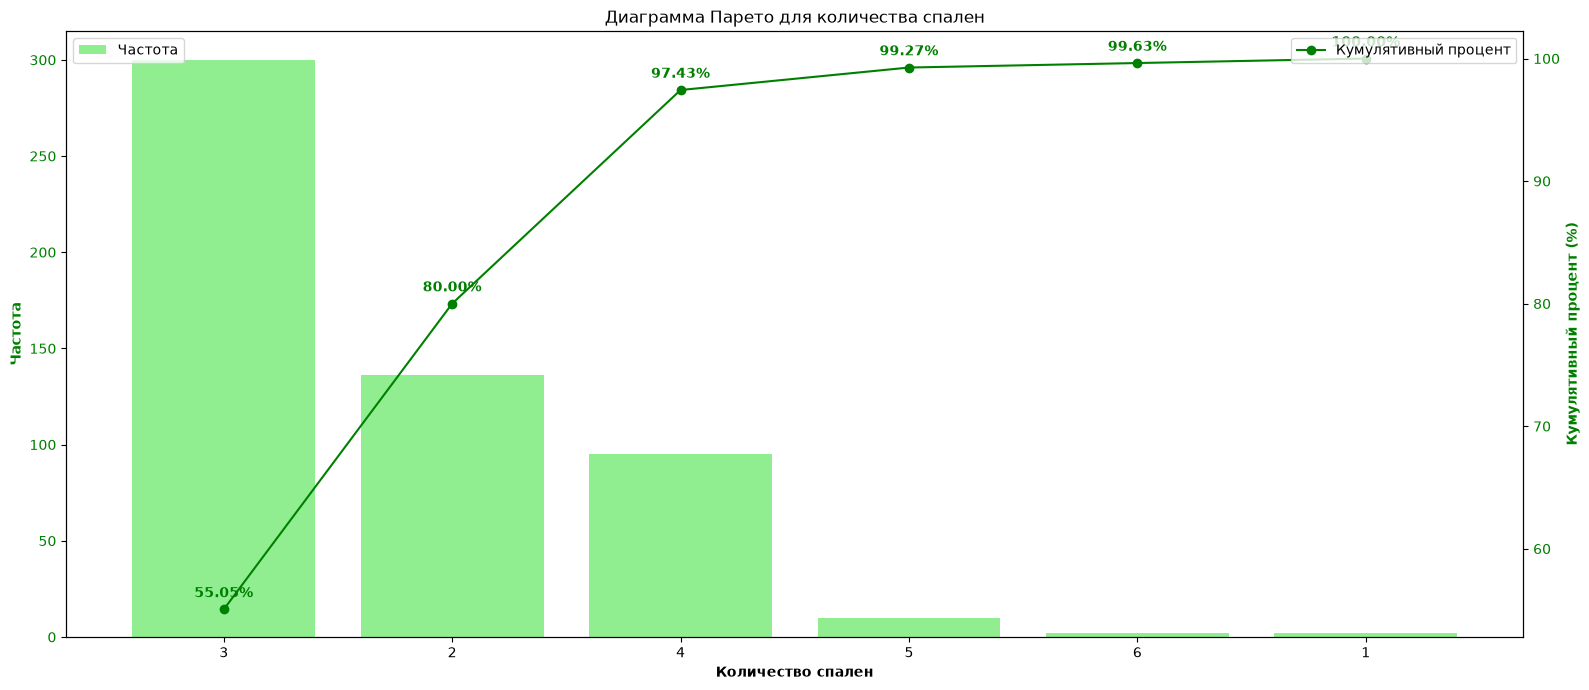

In [70]:
datapareto = data['bedrooms'].value_counts().sort_values(ascending = False)

cumulative = datapareto.cumsum()
cumulative_percentage = 100 * cumulative / cumulative.iloc[-1]

fig, ax1 = plt.subplots(figsize=(16, 7))

ax1.bar(datapareto.index.astype(str), datapareto.values, color='lightgreen', label='Частота')
ax1.set_xlabel('Количество спален', fontweight='bold')
ax1.set_ylabel('Частота', color='green', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='green')

ax2 = ax1.twinx()
ax2.plot(datapareto.index.astype(str), cumulative_percentage, color='green',  marker='o', label='Кумулятивный процент')
ax2.set_ylabel('Кумулятивный процент (%)', color='green', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='green')
for i, value in enumerate(cumulative_percentage):
    ax2.text(i, value + 1, f"{value:.2f}%", ha='center', color='green', fontweight='bold')

plt.title('Диаграмма Парето для количества спален')
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

## Диаграмма рассеяния 
Диаграмма рассеяния — это графический способ отображения взаимосвязи между двумя количественными переменными. Она представляет собой набор точек на координатной плоскости, где каждая точка соответствует паре значений (x, y). Диаграммы рассеяния полезны для визуального анализа корреляции между переменными.

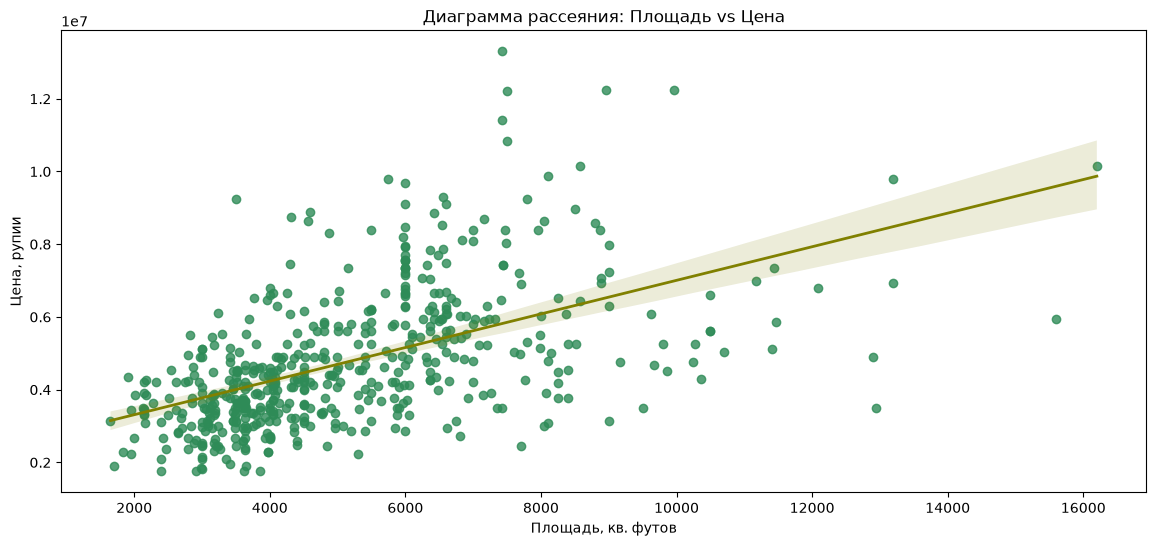

In [71]:
plt.figure(figsize=(14, 6))
sns.regplot(x='area', y='price', data=data, 
            scatter_kws={'color': 'seagreen', 'marker': 'o'},
            line_kws={'color': 'olive', 'linewidth': 2})

plt.title('Диаграмма рассеяния: Площадь vs Цена')
plt.xlabel('Площадь, кв. футов')
plt.ylabel('Цена, рупии')
plt.grid(False)
plt.show()

## Стебле-листовой график
Стебле-листовая диаграмма (stem-and-leaf plot) — это способ визуализации распределения данных, который помогает сохранить оригинальные значения и при этом показывает их распределение. 

In [72]:
grouped = data.groupby('bathrooms')['price'].agg(['sum', 'mean']).reset_index()
grouped['mean'] = grouped['mean'].astype(int) 

stem_leaf = {}

for _, row in grouped.iterrows():
    stem = row['bathrooms']
    total_value = int(row['sum'] / 1000) 
    mean_value = int(row['mean'] / 1000)  
    
    if stem not in stem_leaf:
        stem_leaf[stem] = {'total': [], 'mean': []}
    
    stem_leaf[stem]['total'].append(str(total_value))
    stem_leaf[stem]['mean'].append(str(mean_value))
    
# Вывод диаграммы
print("Стебле-листовая диаграмма для стоимости домов")
print("Кол-во ванных| Суммарная стоимость | Средняя стоимость")
print("-" * 70)

for stem in sorted(stem_leaf.keys()):
    total_leaves = ' '.join(stem_leaf[stem]['total'])
    mean_leaves = ' '.join(stem_leaf[stem]['mean'])
    print(f"{stem} | {total_leaves.ljust(20)} | {mean_leaves}")

Стебле-листовая диаграмма для стоимости домов
Кол-во ванных| Суммарная стоимость | Средняя стоимость
----------------------------------------------------------------------
1 | 1686972              | 4206
2 | 825824               | 6209
3 | 72821                | 7282
4 | 12250                | 12250


In [73]:
grouped = data.groupby('bedrooms')['price'].agg(['sum', 'mean']).reset_index()
grouped['mean'] = grouped['mean'].astype(int) 

stem_leaf = {}

for _, row in grouped.iterrows():
    stem = row['bedrooms']
    total_value = int(row['sum'] / 1000) 
    mean_value = int(row['mean'] / 1000)  
    
    if stem not in stem_leaf:
        stem_leaf[stem] = {'total': [], 'mean': []}
    
    stem_leaf[stem]['total'].append(str(total_value))
    stem_leaf[stem]['mean'].append(str(mean_value))
    
# Вывод диаграммы
print("Стебле-листовая диаграмма для стоимости домов")
print("Кол-во спален| Суммарная стоимость | Средняя стоимость")
print("-" * 70)

for stem in sorted(stem_leaf.keys()):
    total_leaves = ' '.join(stem_leaf[stem]['total'])
    mean_leaves = ' '.join(stem_leaf[stem]['mean'])
    print(f"{stem} | {total_leaves.ljust(20)} | {mean_leaves}")

Стебле-листовая диаграмма для стоимости домов
Кол-во спален| Суммарная стоимость | Средняя стоимость
----------------------------------------------------------------------
1 | 5425                 | 2712
2 | 493955               | 3632
3 | 1486379              | 4954
4 | 544327               | 5729
5 | 58198                | 5819
6 | 9583                 | 4791


In [74]:
grouped = data.groupby('stories')['price'].agg(['sum', 'mean']).reset_index()
grouped['mean'] = grouped['mean'].astype(int) 

stem_leaf = {}

for _, row in grouped.iterrows():
    stem = row['stories']
    total_value = int(row['sum'] / 1000) 
    mean_value = int(row['mean'] / 1000)  
    
    if stem not in stem_leaf:
        stem_leaf[stem] = {'total': [], 'mean': []}
    
    stem_leaf[stem]['total'].append(str(total_value))
    stem_leaf[stem]['mean'].append(str(mean_value))
    
# Вывод диаграммы
print("Стебле-листовая диаграмма для количества этажей")
print("Кол-во этажей| Суммарная стоимость | Средняя стоимость")
print("-" * 70)

for stem in sorted(stem_leaf.keys()):
    total_leaves = ' '.join(stem_leaf[stem]['total'])
    mean_leaves = ' '.join(stem_leaf[stem]['mean'])
    print(f"{stem} | {total_leaves.ljust(20)} | {mean_leaves}")

Стебле-листовая диаграмма для количества этажей
Кол-во этажей| Суммарная стоимость | Средняя стоимость
----------------------------------------------------------------------
1 | 946739               | 4170
2 | 1133849              | 4764
3 | 221732               | 5685
4 | 295546               | 7208


## Паралельные координаты

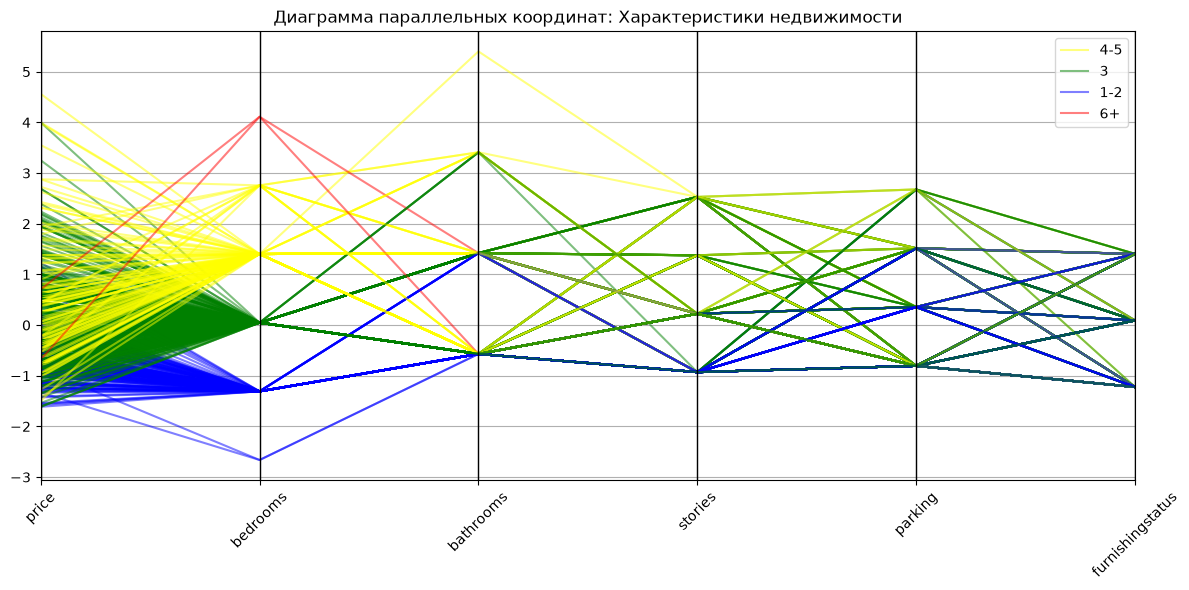

In [75]:
numeric_cols = ['price','bedrooms', 'bathrooms', 'stories', 'parking', 'furnishingstatus']

# Нормализуем данные для одинакового масштаба осей
data_normalized = (data[numeric_cols] - data[numeric_cols].mean()) / data[numeric_cols].std()

# Добавляем категориальную переменную для цветовой группировки (по количеству спален)
data_normalized['bedrooms_group'] = pd.cut(data['bedrooms'], 
                                          bins=[0, 2, 3, 5, 6],
                                          labels=['1-2', '3', '4-5','6+'])

# Строим диаграмму
plt.figure(figsize=(12, 6))
parallel_coordinates(data_normalized, 'bedrooms_group', 
                   color=('yellow', 'green', 'blue', 'red'),
                   alpha=0.5)
plt.title('Диаграмма параллельных координат: Характеристики недвижимости')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Отношение шансов


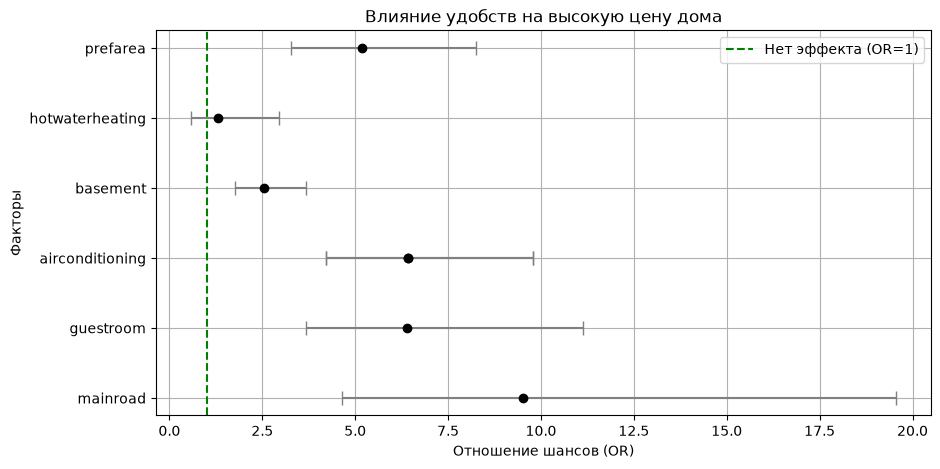

In [76]:
data['high_price'] = (data['price'] > data['price'].median()).astype(int)

factors = ['mainroad', 'guestroom', 'airconditioning', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
results = []

# Расчет OR для каждого фактора
for factor in factors:
    # Логистическая регрессия
    X = sm.add_constant(data[factor])
    y = data['high_price']
    model = sm.Logit(y, X).fit(disp=0)
    
    # Сохраняем OR и доверительный интервал 
    or_val = np.exp(model.params.iloc[1]) 
    ci_low, ci_high = np.exp(model.conf_int().iloc[1])
    results.append({
        'factor': factor,
        'OR': or_val,
        'CI_low': ci_low,
        'CI_high': ci_high
    })

results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
plt.errorbar(
    x=results_df['OR'],
    y=results_df['factor'],
    xerr=[results_df['OR'] - results_df['CI_low'], results_df['CI_high'] - results_df['OR']],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=5
)
plt.axvline(x=1, color='green', linestyle='--', label='Нет эффекта (OR=1)')
plt.xlabel('Отношение шансов (OR)')
plt.ylabel('Факторы')
plt.title('Влияние удобств на высокую цену дома')
plt.legend()
plt.grid(True)
plt.show()

## Визуализация на основе глифов (лиц Чернова)

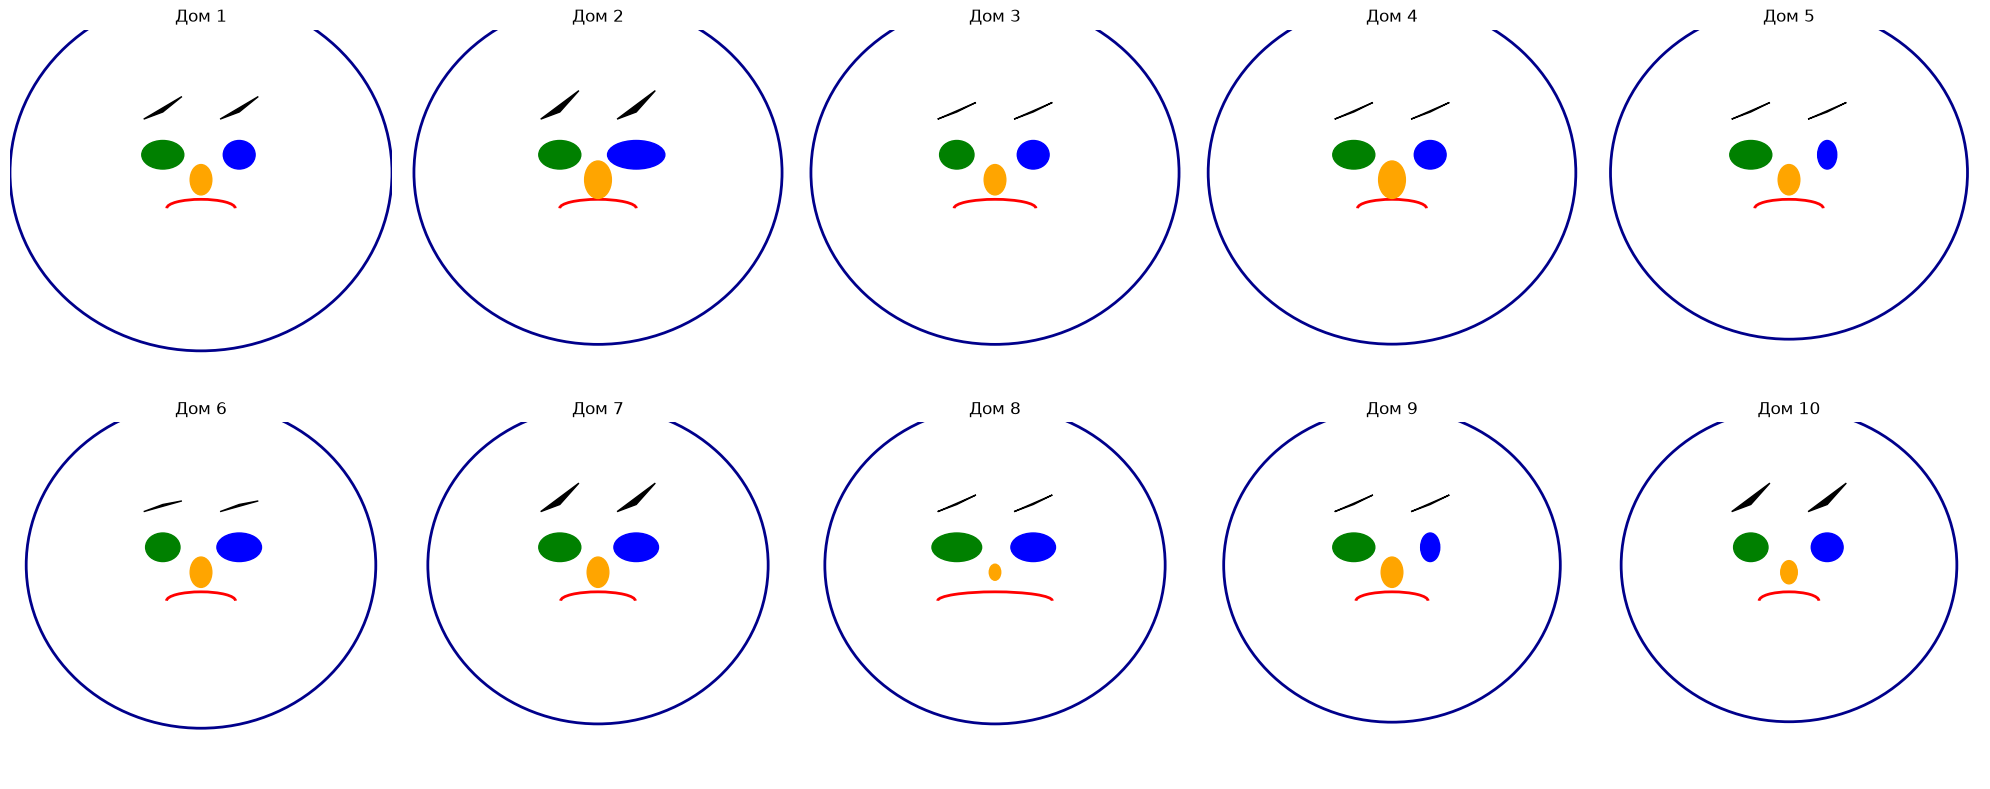

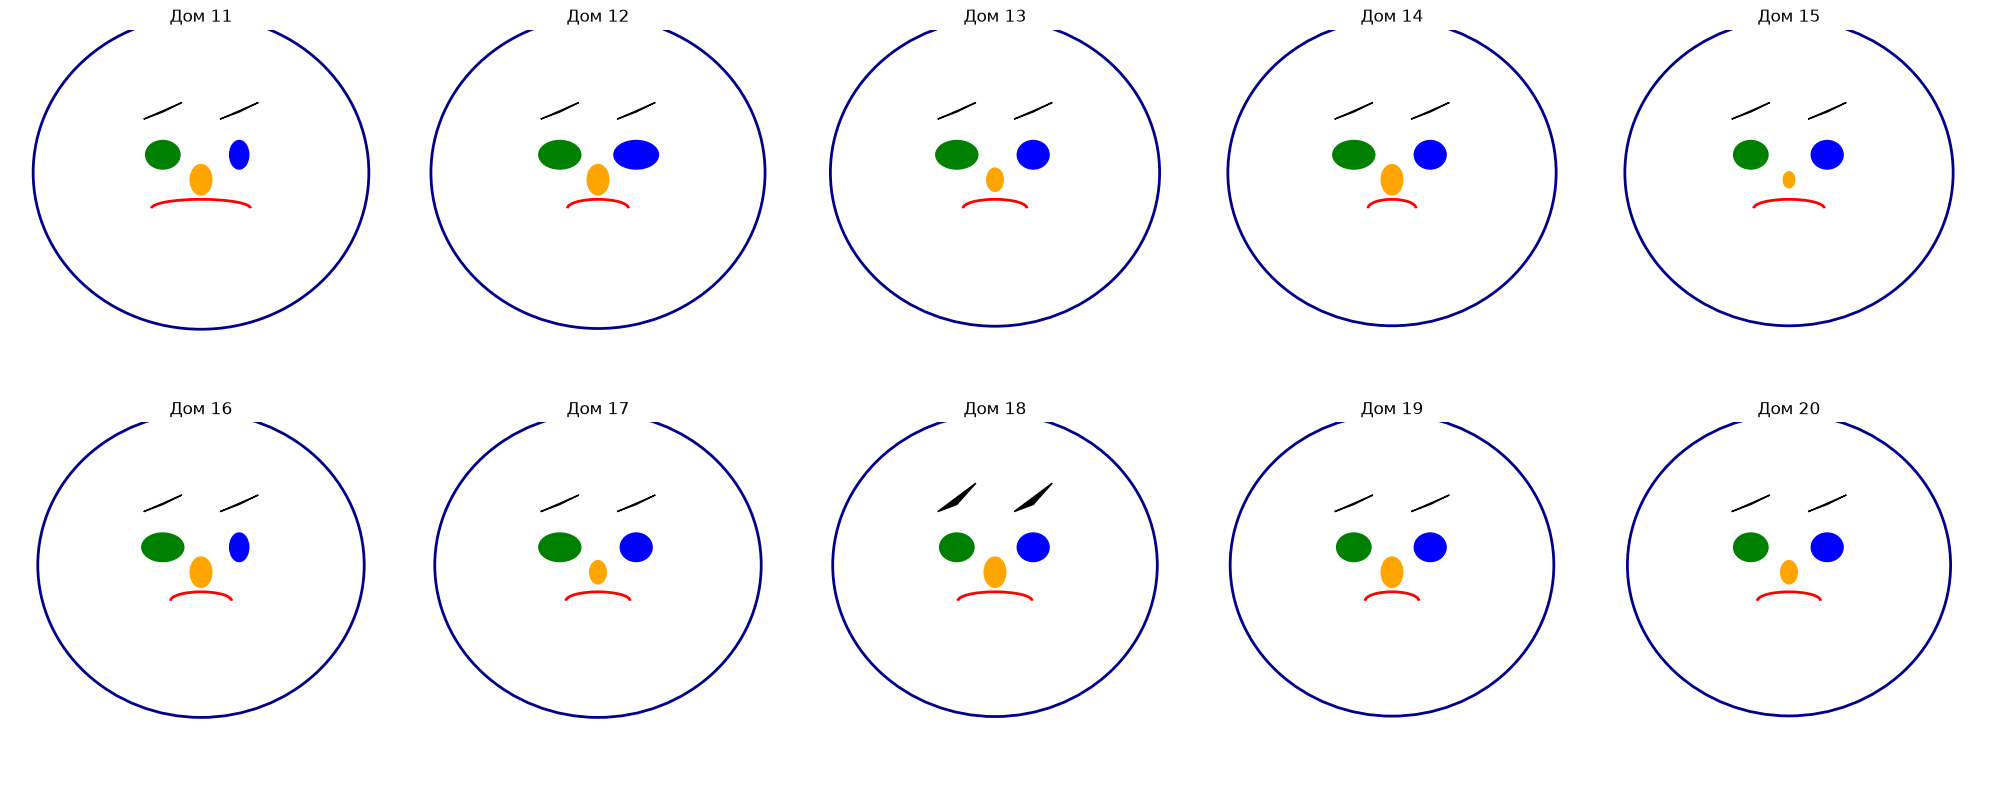

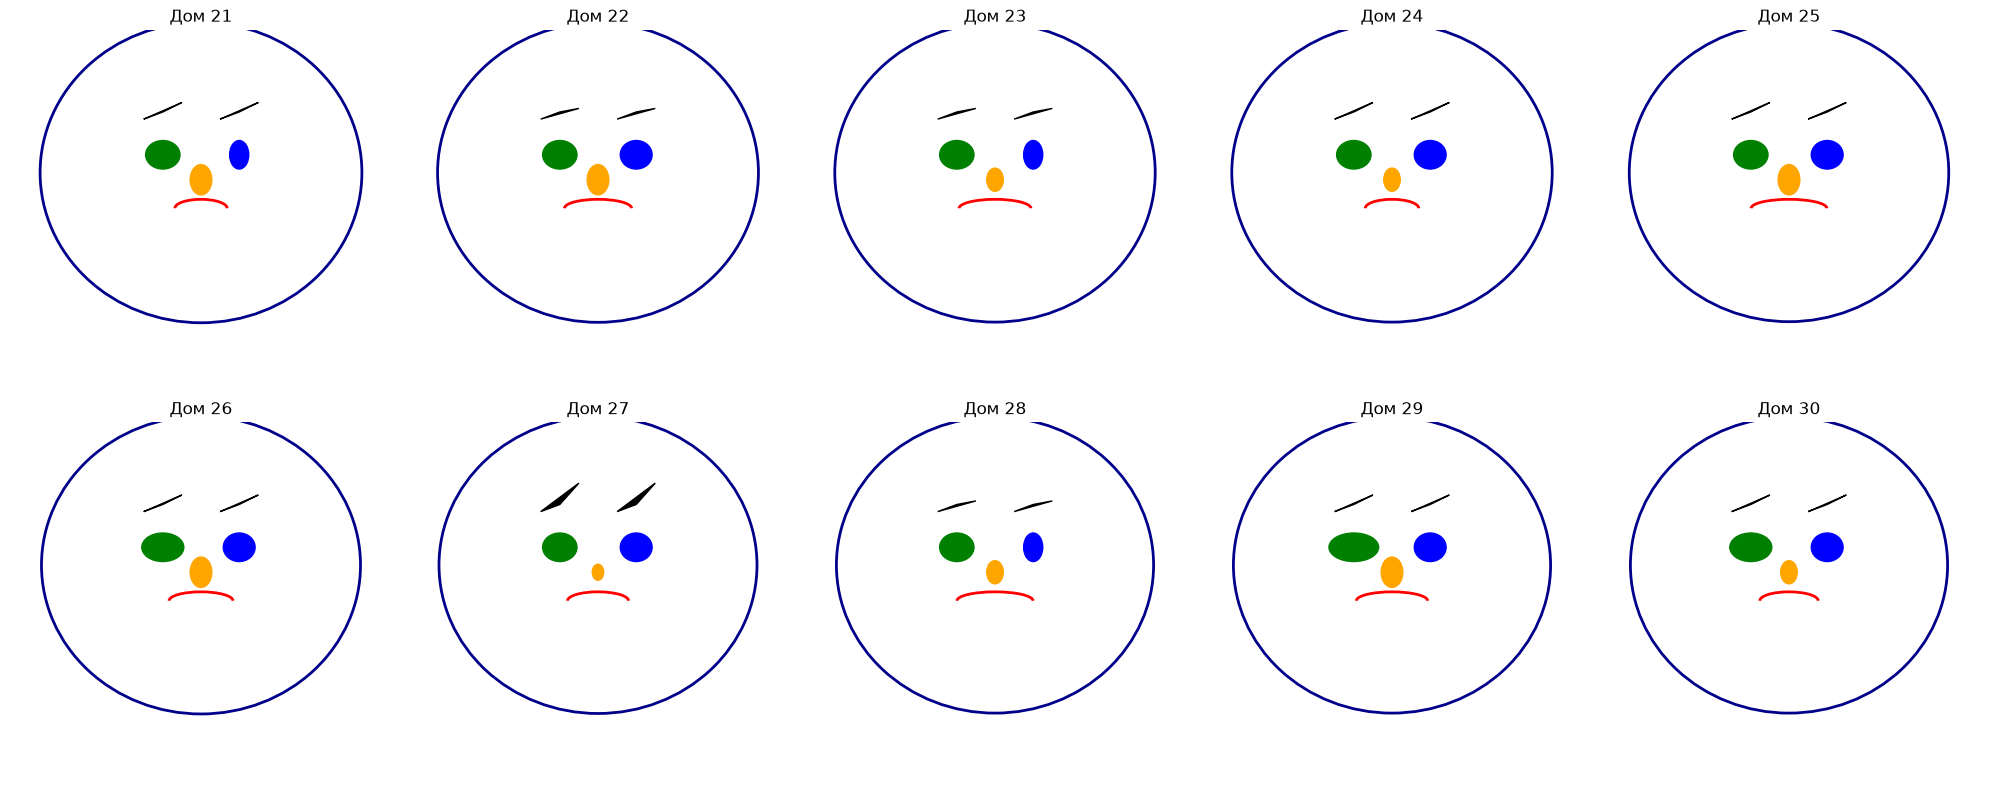

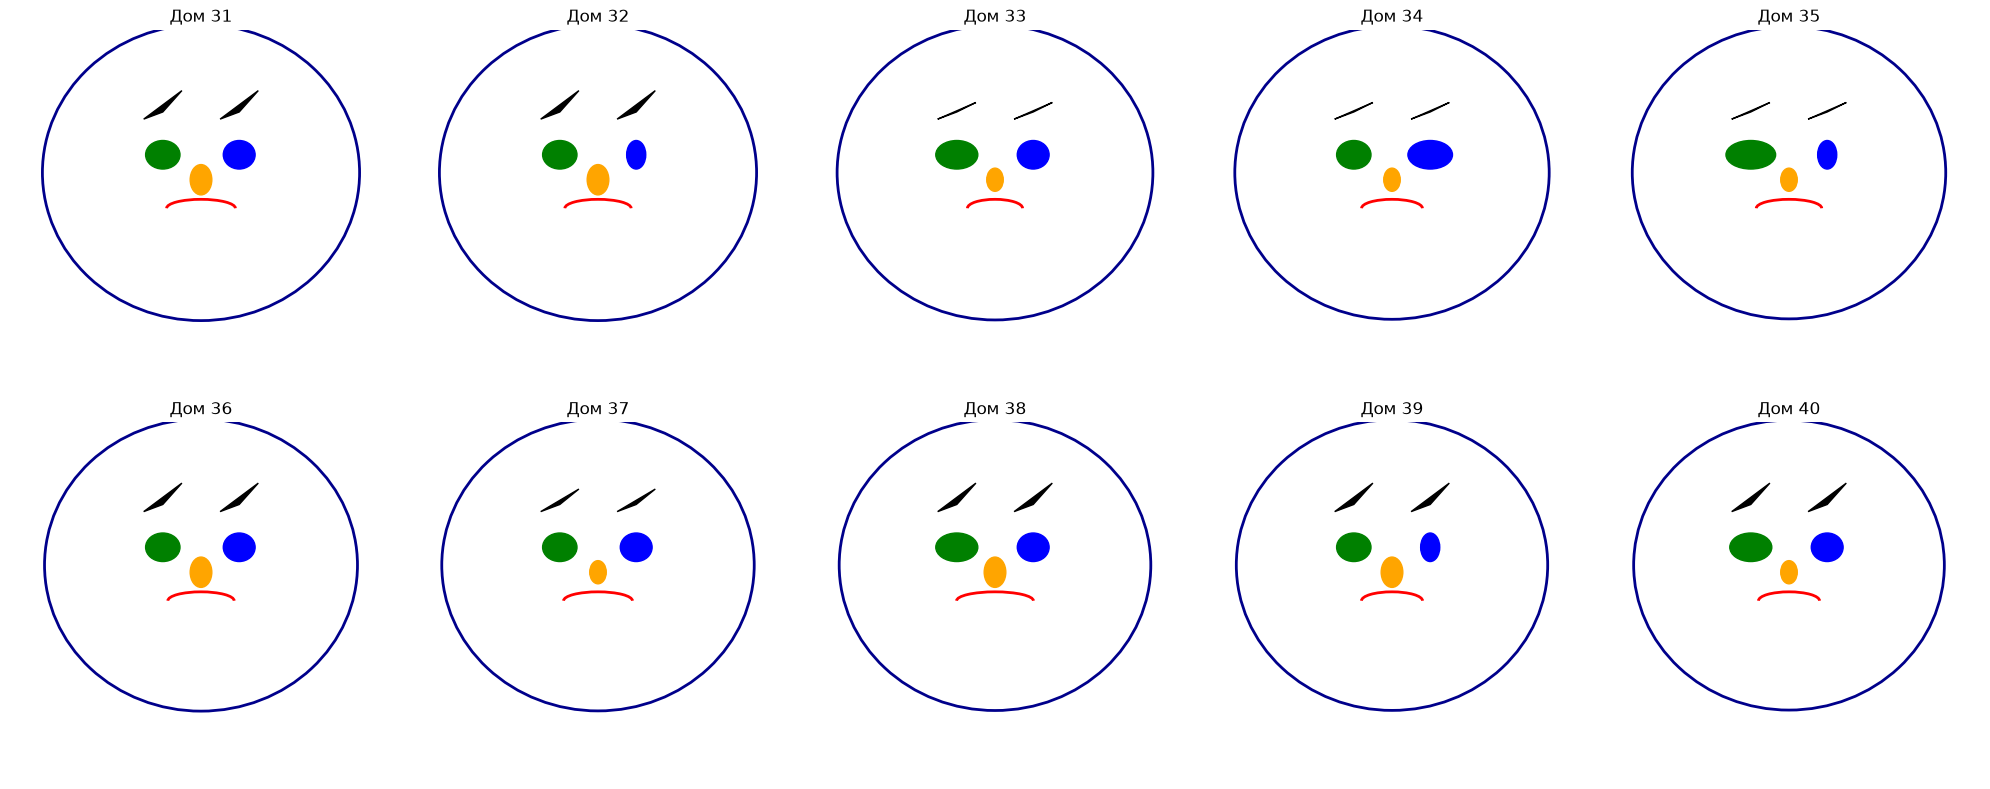

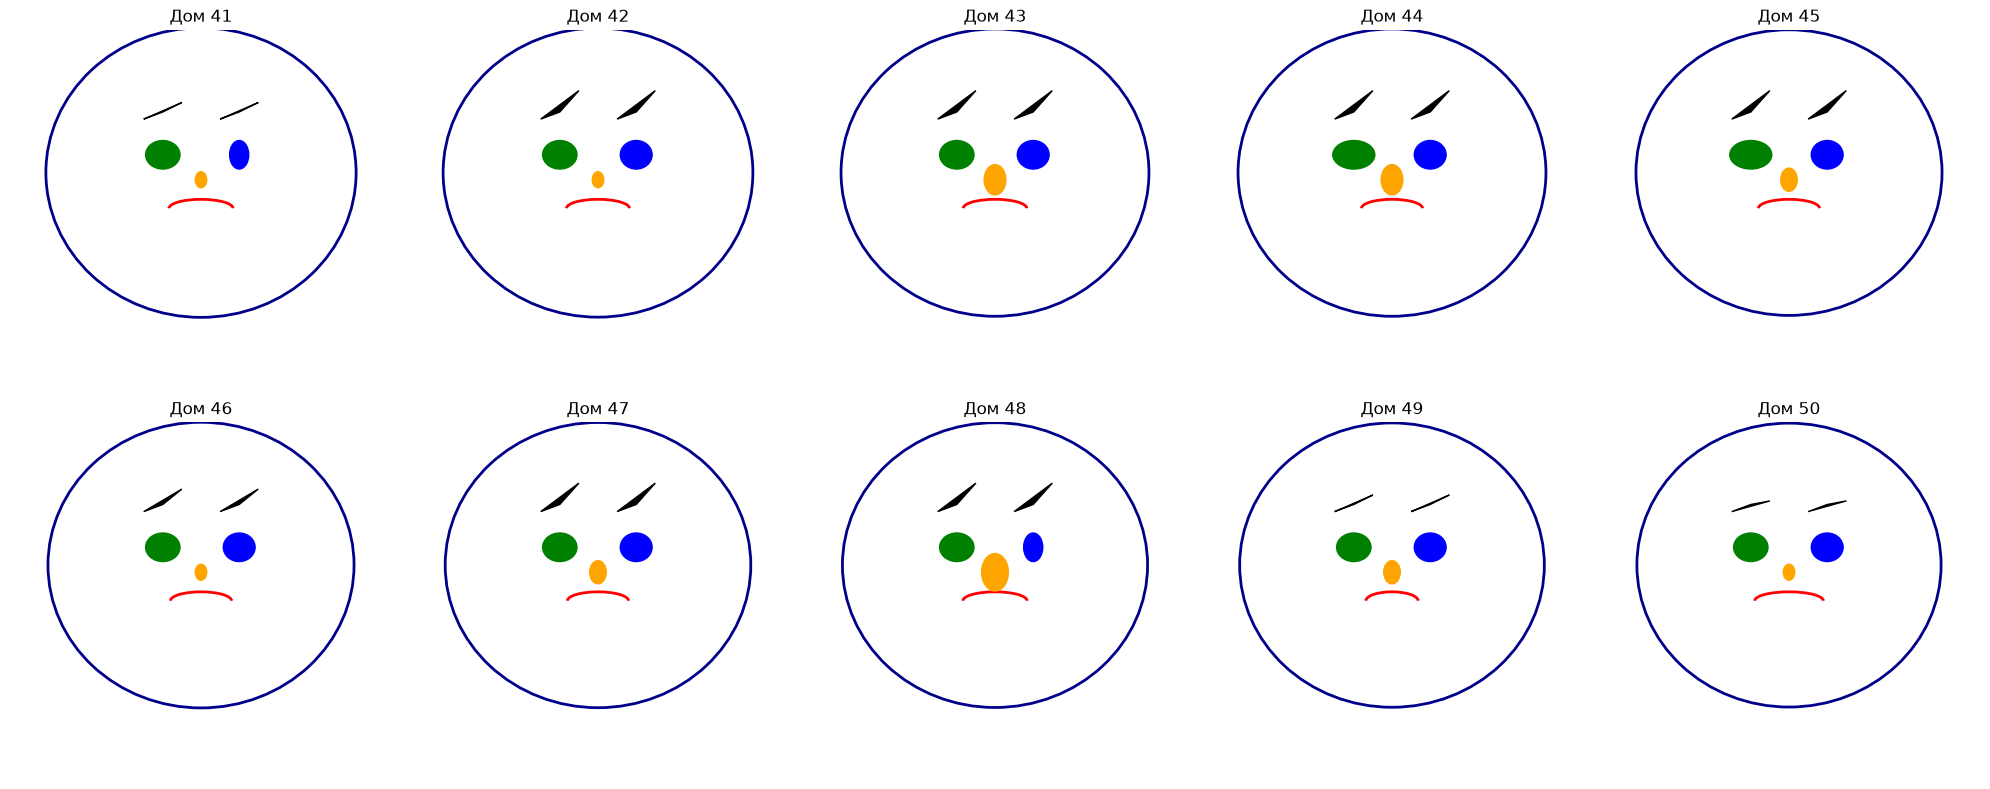

In [77]:
params = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
df = data[params].copy()

# Нормализация (0-1)
df_norm = (df - df.min()) / (df.max() - df.min())
def create_house_face(ax, values):
    """Создает лицо Чернова для дома."""
    # Распределение параметров по чертам лица:
    price, area, bedrooms, bathrooms, stories, parking = values
    
    # Голова (общая стоимость)
    head_size = 0.3 + 0.2 * price
    head = Circle((0.5, 0.6), head_size, fill=False, edgecolor='darkblue', lw=2)
    ax.add_patch(head)
    
    # Глаза (спальни и ванные)
    left_eye = Ellipse((0.4, 0.65), 0.05 + 0.1 * bedrooms, 0.08, fill=True, color='green')
    right_eye = Ellipse((0.6, 0.65), 0.05 + 0.1 * bathrooms, 0.08, fill=True, color='blue')
    ax.add_patch(left_eye)
    ax.add_patch(right_eye)
    
    # Рот (площадь)
    mouth_width = 0.1 + 0.2 * area
    mouth = Arc((0.5, 0.5), mouth_width, 0.05, theta1=0, theta2=180, edgecolor='red', lw=2)
    ax.add_patch(mouth)
    
    # Брови (этажность)
    left_brow = Polygon([[0.35, 0.75], [0.45, 0.78 + 0.05 * stories], [0.4, 0.77]], 
                       fill=True, color='black')
    right_brow = Polygon([[0.55, 0.75], [0.65, 0.78 + 0.05 * stories], [0.6, 0.77]], 
                        fill=True, color='black')
    ax.add_patch(left_brow)
    ax.add_patch(right_brow)
    
    # Нос (парковка)
    nose_size = 0.03 + 0.04 * parking
    nose = Ellipse((0.5, 0.58), nose_size, nose_size*1.5, fill=True, color='orange')
    ax.add_patch(nose)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
from IPython.display import display, HTML

n_houses = 50  # Общее число домов
per_page = 10  # Домов на страницу

for page in range(0, n_houses, per_page):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for i in range(per_page):
        if page + i >= n_houses:
            break
        row = i // 5
        col = i % 5
        create_house_face(axes[row, col], df_norm.iloc[page + i].values)
        axes[row, col].set_title(f"Дом {page+i+1}")
    plt.tight_layout()
    display(fig)
    plt.close()
    display(HTML('<hr style="height:3px;border:none;color:#333;background-color:#333;" />'))

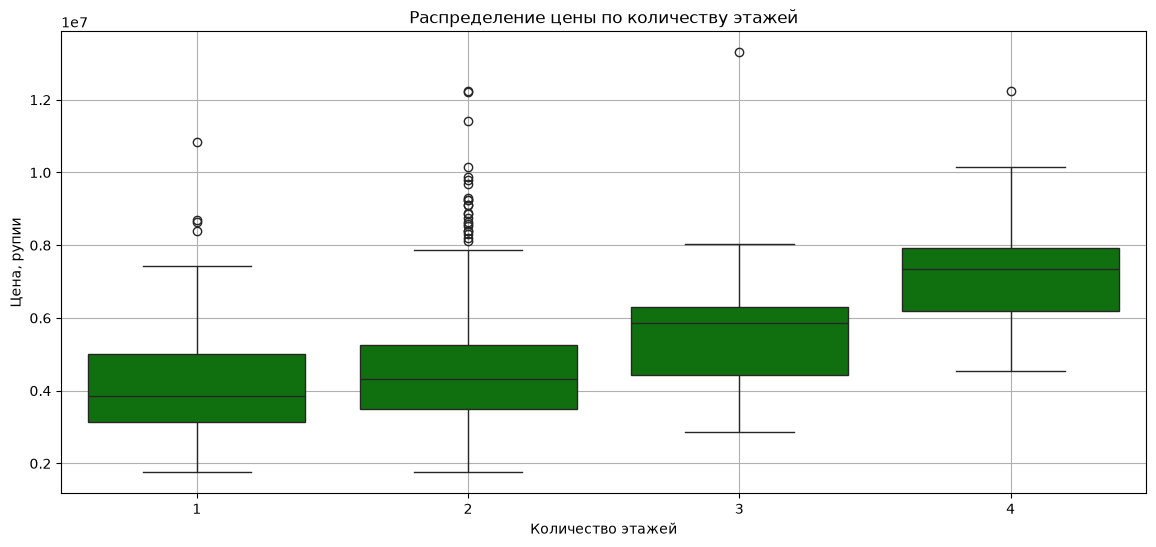

In [78]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='stories', y='price', data=data, color ='green')
plt.title('Распределение цены по количеству этажей')
plt.xlabel('Количество этажей')
plt.ylabel('Цена, рупии')
plt.grid(True)
plt.show()

## Диаграмма размаха для bedrooms

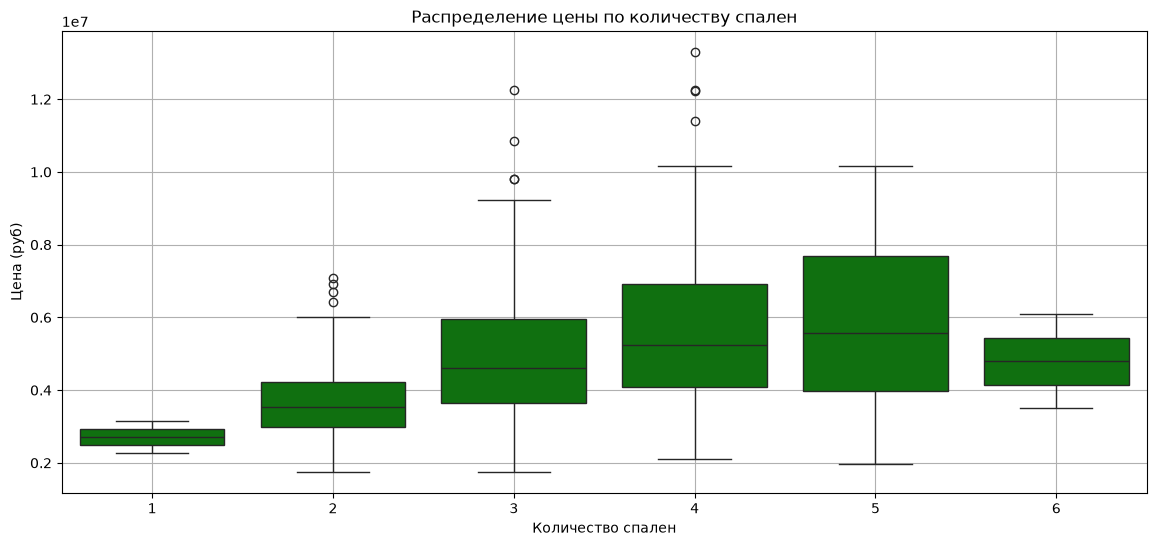

In [79]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='bedrooms', y='price', data=data, color ='green')
plt.title('Распределение цены по количеству спален')
plt.xlabel('Количество спален')
plt.ylabel('Цена (руб)')
plt.grid(True)
plt.show()

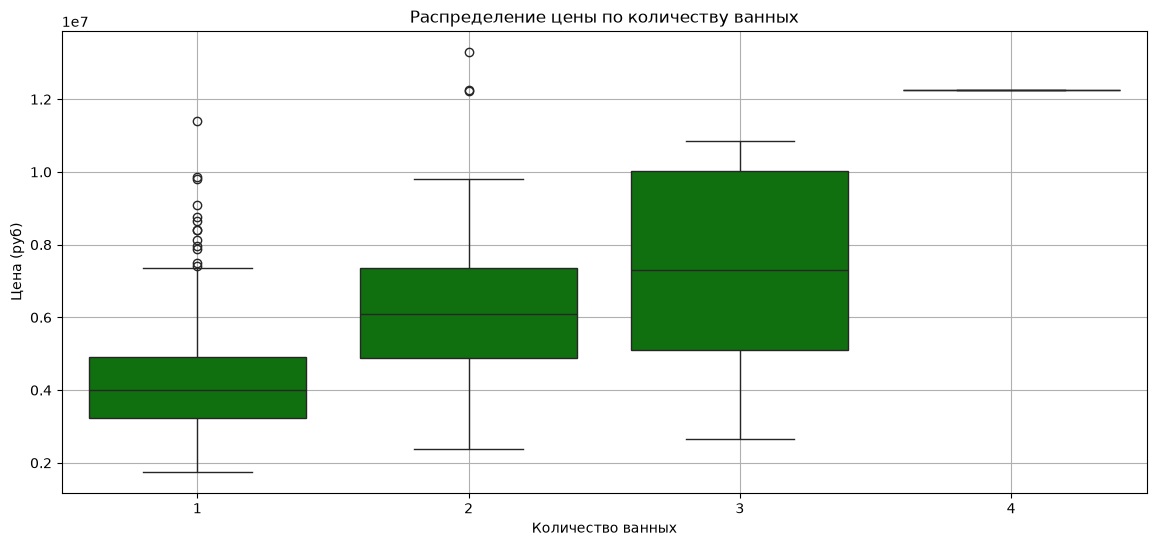

In [80]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='bathrooms', y='price', data=data, color ='green')
plt.title('Распределение цены по количеству ванных')
plt.xlabel('Количество ванных')
plt.ylabel('Цена (руб)')
plt.grid(True)
plt.show()

# ЧАСТЬ 2
## Особенности эмпирического распределения
### Гистограммы

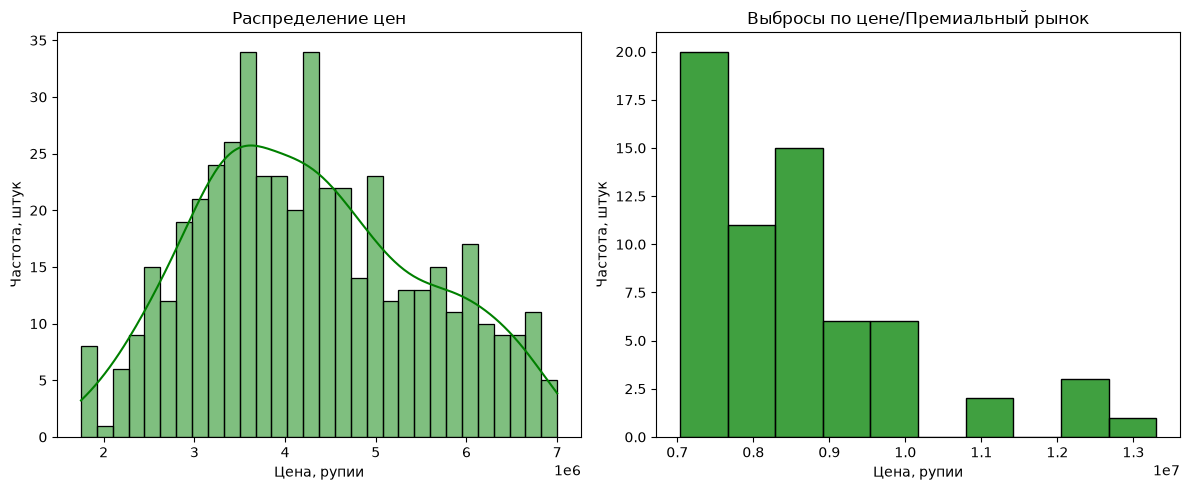

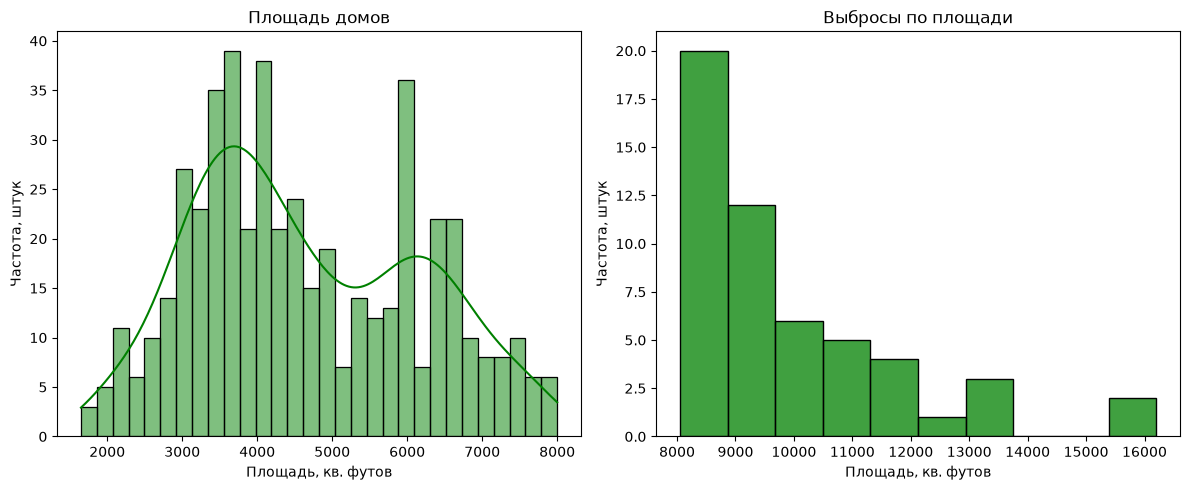

In [81]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Распределение цен')
plt.xlabel('Цена, рупии')
plt.ylabel('Частота, штук')
sns.histplot(data[data.price <= 7000000].price, color='green', bins=30, kde=True)


plt.subplot(1, 2, 2)
plt.title('Выбросы по цене/Премиальный рынок')
plt.xlabel('Цена, рупии')
plt.ylabel('Частота, штук')
sns.histplot(data[data.price > 7000000].price, color='green', bins=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title('Площадь домов')
plt.xlabel('Площадь, кв. футов')
plt.ylabel('Частота, штук')
sns.histplot(data[data.area <= 8000].area, color='green', bins=30, kde=True)

plt.subplot(1, 2, 2)
plt.title('Выбросы по площади')
plt.xlabel('Площадь, кв. футов')
plt.ylabel('Частота, штук')
sns.histplot(data[data.area > 8000].area, color='green', bins=10)
plt.tight_layout()
plt.show()

1. Основное распределение цен (первый график)
- Основная масса домов сосредоточена в диапазоне 2–6 млн рупий;
- Наибольшее количество домов (≈37 штук) имеет цену около 4.2 млн рупий;
- Правосторонная ассиметрия;
- Большинство предложений — бюджетные и среднего ценового сегмента.
Вывод: Рынок ориентирован на массового покупателя, но есть небольшой сегмент дорогих домов.
2. Выбросы по цене (второй график)
- Крайне малое количество (≤5 домов на каждый диапазон);
- Это могут быть элитные дома или коммерческая недвижимость.
Вывод: Для анализа лучше изучить эти объекты отдельно (например, проверить наличие дополнительных признаков: бассейн, расположение в престижном районе).
3. Основное распределение площади (третий график)
- Основная часть домов имеет площадь 3000–4500 кв. футов, также 6000;
- Максимум приходится на 4800 кв. футов (≈38 домов);
- Ближе к нормальному, но с легким правым перекосом.
Вывод: Стандартные размеры жилья соответствуют спросу на семьи среднего класса.
4. Выбросы по площади (четвертый график)
- Малое количество от 1 до 12.
Вывод: Если ошибок нет — выделить эти объекты в отдельную категорию (возможно коммерческая недвижимость).

# Ассиметрия 

In [82]:
skew_price = data['price'].skew()
rounded_skewp = round(skew_price, 2)
print(f"Асимметрия цены: {rounded_skewp}")

skew_area = data['area'].skew()
rounded_skewa = round(skew_area, 2)
print(f"Асимметрия площади: {rounded_skewa}")
print(f"{rounded_skewp} и  {rounded_skewa}  > 1 - значительная ассиметрия. Правый перекос (длинный хвост в сторону больших значений).")

Асимметрия цены: 1.21
Асимметрия площади: 1.32
1.21 и  1.32  > 1 - значительная ассиметрия. Правый перекос (длинный хвост в сторону больших значений).


# Эксцесс

In [83]:
kurtosisprice = data['price'].kurtosis()
roundedkurtosisprice = round(kurtosisprice, 2)
print(f"Эксцесс цены: {roundedkurtosisprice}")

kurtosisarea = data['area'].kurtosis()
roundedkurtosisarea = round(kurtosisarea, 2)
print(f"Эксцесс площади: {roundedkurtosisarea}")

Эксцесс цены: 1.96
Эксцесс площади: 2.75


1. Эксцесс цены: 1.96
- Распределение цен является лептокуртическим (более островершинным);
- Наличие тяжелых хвостов - больше экстремальных значений, чем ожидалось бы при нормальном распределении.

Вероятные причины:
1) Наличие небольшого количества очень дорогих домов (выбросы в правом хвосте)
2) Концентрация большинства цен в узком диапазоне с резким падением частот по краям
2. Эксцесс площади: 2.75
- Еще более выраженная островершинность по сравнению с ценами (экстремальное распределение);
- Сильно тяжелые хвосты - значительное количество объектов с большой площадью;
- Большинство домов имеют близкие по значению площади.

# Выбросы

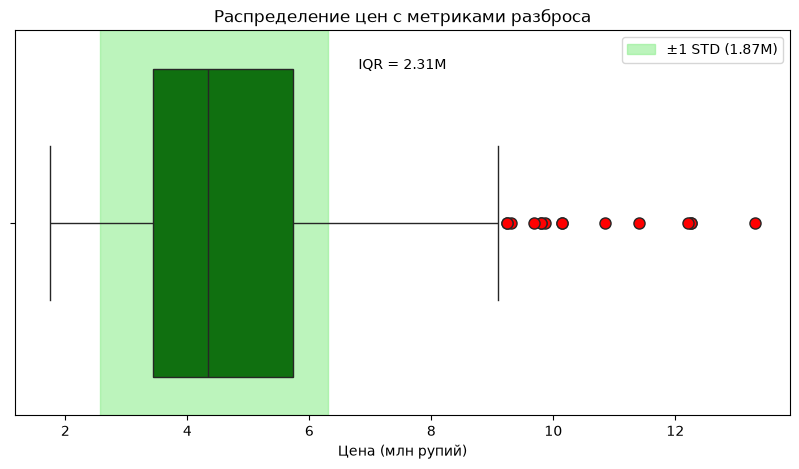

In [84]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=data['price']/1e6, color='green', 
            flierprops={'marker': 'o', 'markersize': 8, 'markerfacecolor': 'red'})

plt.text(0.5, 0.9, f"IQR = {2.31}M", transform=plt.gca().transAxes, ha='center')
plt.axvspan(4.44-1.87, 4.44+1.87, alpha=0.6, color='lightgreen', label='±1 STD (1.87M)')
plt.xlabel('Цена (млн рупий)')
plt.title('Распределение цен с метриками разброса')
plt.legend()
plt.show()

1. Ящик по цене
На графике видно довольно много точек выше 9 млн рупий, что подтверждает наличие выбросов.
Дома дороже 10 млн рупий статистически аномальны
Возможные причины:
Элитная недвижимость (особняки, пентхаусы);
Ошибки данных (лишний ноль в записи).

2. Ящик по площади
На графике точек выбросов гораздо меньше чем у цены, что подтверждает слова о не такой большой ассиметрии, но такие значения все равно считаются статистическими выбросами.
Возможные объяснения:
Коммерческая недвижимость (офисы, магазины);
Ошибки в единицах измерения (например, метры вместо футов);
Особняки с огромными участками.

bathrooms
1    0.735780
2    0.244037
3    0.018349
4    0.001835
Name: proportion, dtype: float64
airconditioning
0    0.684404
1    0.315596
Name: proportion, dtype: float64


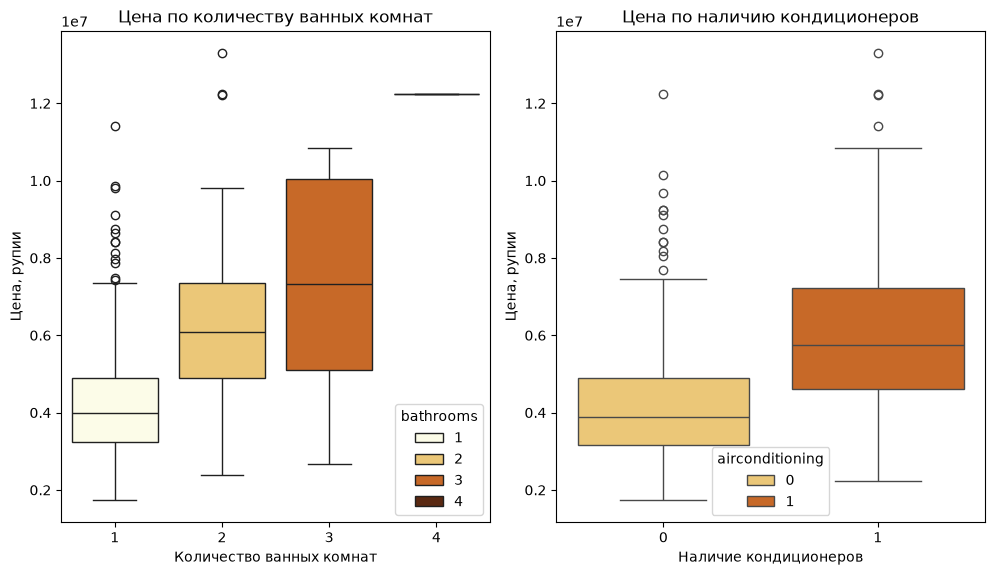

In [85]:

plt.figure(figsize=(15, 6))
print(data['bathrooms'].value_counts(normalize=True))
plt.subplot(1, 3, 1)
sns.boxplot(x='bathrooms', y='price', hue='bathrooms', data=data, palette='YlOrBr')
plt.title('Цена по количеству ванных комнат')
plt.xlabel('Количество ванных комнат')
plt.ylabel('Цена, рупии')

print(data['airconditioning'].value_counts(normalize=True))
plt.subplot(1, 3, 2)
sns.boxplot(x='airconditioning', y='price', hue='airconditioning', data=data, palette='YlOrBr')
plt.title('Цена по наличию кондиционеров')
plt.xlabel('Наличие кондиционеров')
plt.ylabel('Цена, рупии')

plt.tight_layout()
plt.show()

# Корреляция Пирсона

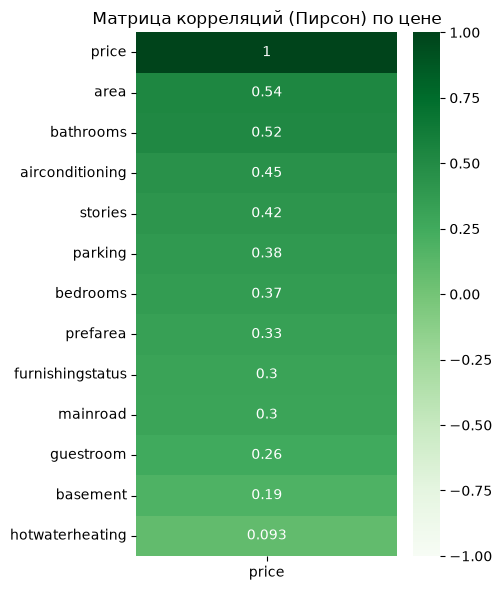

In [86]:
numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 
                'mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
numeric_df = data[numeric_cols]

corr_matrix = numeric_df.corr(method='pearson')

heatmap_price = corr_matrix['price'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(5, 6))
sns.heatmap(heatmap_price, annot=True, cmap='Greens', vmin=-1, vmax=1, center=0)
plt.title('Матрица корреляций (Пирсон) по цене')
plt.tight_layout()
plt.show()

# Корреляция Спирмена

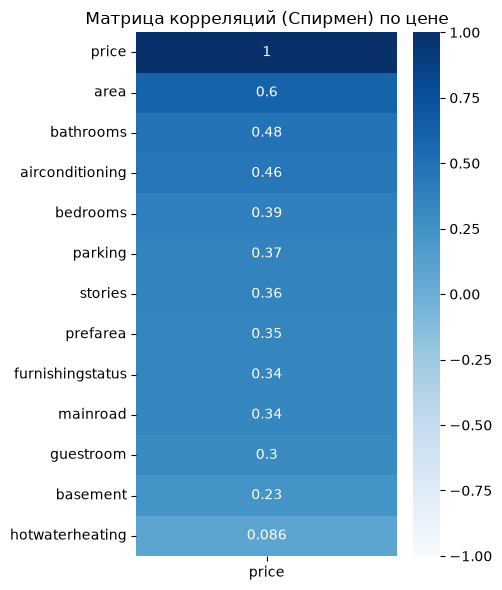

In [87]:
numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 
                'mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
numeric_df = data[numeric_cols]

corr_matrix = numeric_df.corr(method='spearman')

heatmap_price = corr_matrix['price'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(5, 6))
sns.heatmap(heatmap_price, annot=True, cmap='Blues', vmin=-1, vmax=1, center=0)
plt.title('Матрица корреляций (Спирмен) по цене')
plt.tight_layout()
plt.show()

# Корреляция Кенделла

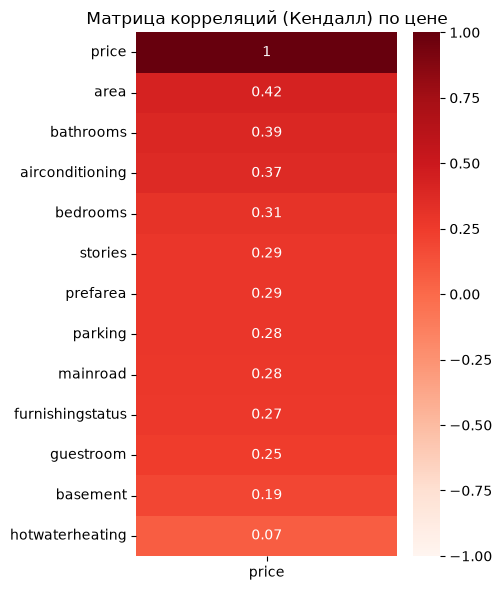

In [88]:
numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 
                'mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
numeric_df = data[numeric_cols]

corr_matrix = numeric_df.corr(method='kendall')

heatmap_price = corr_matrix['price'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(5, 6))
sns.heatmap(heatmap_price, annot=True, cmap='Reds', vmin=-1, vmax=1, center=0)
plt.title('Матрица корреляций (Кендалл) по цене')
plt.tight_layout()
plt.show()

# Факторая регрессия

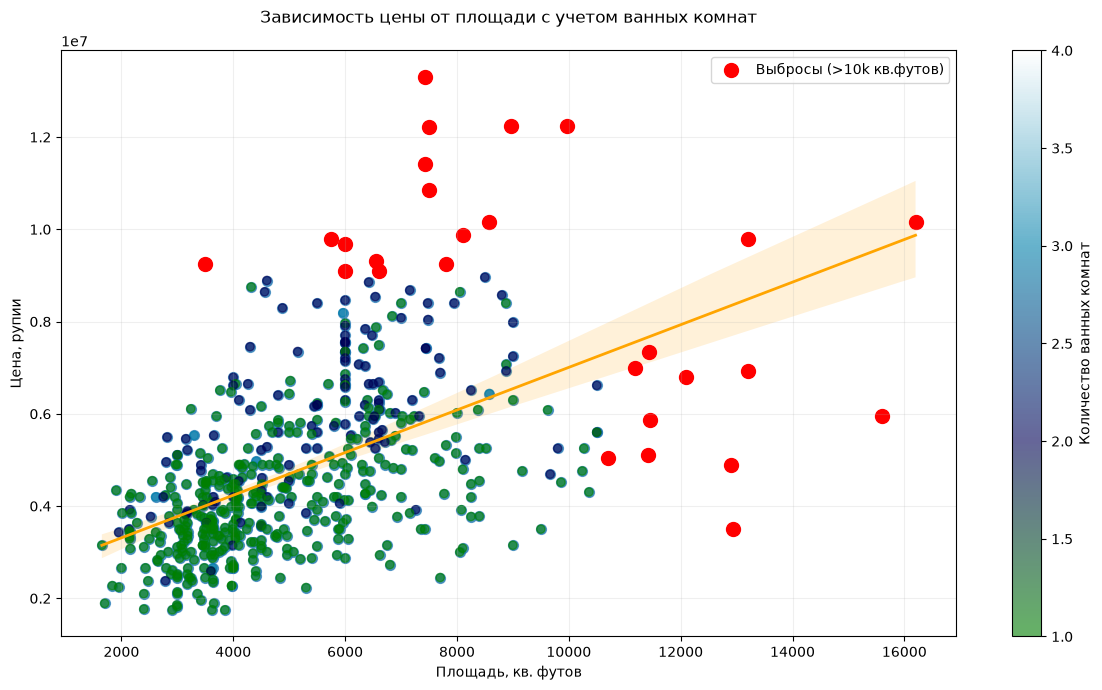

In [89]:
plt.figure(figsize=(12, 7))

sample_data = data
sns.regplot(
    x='area',
    y='price',
    data=sample_data,
    scatter_kws={'s': 50, 'alpha': 0.7},
    line_kws={'color': 'orange', 'lw': 2},
    ci=95 
)

scatter = plt.scatter(
    x=sample_data['area'],
    y=sample_data['price'],
    c=sample_data['bathrooms'],
    cmap='ocean',
    alpha=0.6
)
plt.colorbar(scatter, label='Количество ванных комнат')
plt.title('Зависимость цены от площади с учетом ванных комнат', pad=20)
plt.xlabel('Площадь, кв. футов')
plt.ylabel('Цена, рупии')
plt.grid(alpha=0.2)

outliers_mask = (sample_data['area'] > 10500) | (sample_data['price'] > 9000000)
if outliers_mask.any():
    outliers = sample_data[outliers_mask]
    plt.scatter(
        outliers['area'],
        outliers['price'],
        c='red',
        s=100,
        label='Выбросы (>10k кв.футов)'
    )
    plt.legend()



plt.tight_layout()
plt.show()

# Средние показатели

In [90]:
from scipy import stats

# Для дискретных значений (ванные комнаты)
bath_mode = stats.mode(data['bathrooms'], keepdims=True)
print(f"Мода ванных комнат: {bath_mode.mode[0]} (встречается {bath_mode.count[0]} раз)")

# Арифметическое среднее
mean_price = np.mean(data['price'])
print(f"Средняя цена: {mean_price/1e6:.2f} млн рупий")

# Мода по диапазону
price_bins = pd.cut(data['price'], bins=20)
price_mode = price_bins.value_counts().idxmax()
print(f"Наиболее частый ценовой диапазон: {price_mode}")

#Медиана
median_price = np.median(data['price'])
q25, q75 = np.percentile(data['price'], [25, 75])
print(f"Медиана цены: {median_price/1e6:.2f} млн рупий")
print(f"25-й перцентиль: {q25/1e6:.2f} млн")
print (f"75-й перцентиль: {q75/1e6:.2f} млн")

# Гармоническое среднее 
harm_mean = stats.hmean(data['price'])
print(f"Гармоническое среднее цены: {harm_mean/1e6:.2f} млн рупий")

# Геометрическое среднее
geom_mean = stats.gmean(data['price'])
print(f"Геометрическое среднее цены: {geom_mean/1e6:.2f} млн рупий")

# Средневзвешенное
weighted_mean = np.average(data['price'], weights=data['area'])
print(f"Взвешенное среднее (по площади): {weighted_mean/1e6:.2f} млн рупий")

# Стандартное отклонение
std_price = np.std(data['price'])
print(f"Стандартное отклонение цены: {std_price/1e6:.2f} млн рупий")

# Дисперсия
var_price = np.var(data['price'])
print(f"Дисперсия цены: {var_price/1e12:.2f} (трлн рупий)²")

# MAD (Median Absolute Deviation)
mad_price = stats.median_abs_deviation(data['price'])
print(f"MAD цены: {mad_price/1e6:.2f} млн рупий")

# IQR (Interquartile Range)
iqr = q75 - q25
print(f"IQR цены: {iqr/1e6:.2f} млн рупий")

Мода ванных комнат: 1 (встречается 401 раз)
Средняя цена: 4.77 млн рупий
Наиболее частый ценовой диапазон: (3482500.0, 4060000.0]
Медиана цены: 4.34 млн рупий
25-й перцентиль: 3.43 млн
75-й перцентиль: 5.74 млн
Гармоническое среднее цены: 4.15 млн рупий
Геометрическое среднее цены: 4.44 млн рупий
Взвешенное среднее (по площади): 5.19 млн рупий
Стандартное отклонение цены: 1.87 млн рупий
Дисперсия цены: 3.49 (трлн рупий)²
MAD цены: 1.05 млн рупий
IQR цены: 2.31 млн рупий


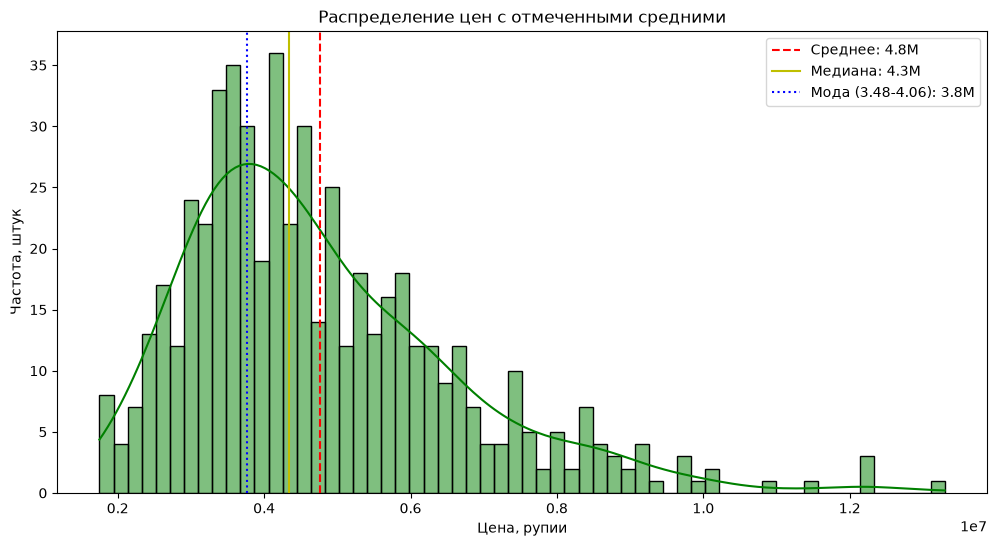

In [91]:
plt.figure(figsize=(12, 6))
sns.histplot(data['price'], bins=60, color = 'green', kde=True)
plt.axvline(mean_price, color='r', linestyle='--', label=f'Среднее: {mean_price/1e6:.1f}M')
plt.axvline(median_price, color='y', linestyle='-', label=f'Медиана: {median_price/1e6:.1f}M')
mode_center = price_mode.mid
plt.axvline(mode_center, color='b', linestyle=':', label=f'Мода ({price_mode.left/1e6:.2f}-{price_mode.right/1e6:.2f}): {mode_center/1e6:.1f}M')
plt.title('Распределение цен с отмеченными средними')
plt.xlabel('Цена, рупии')
plt.ylabel('Частота, штук')
plt.legend()
plt.show()

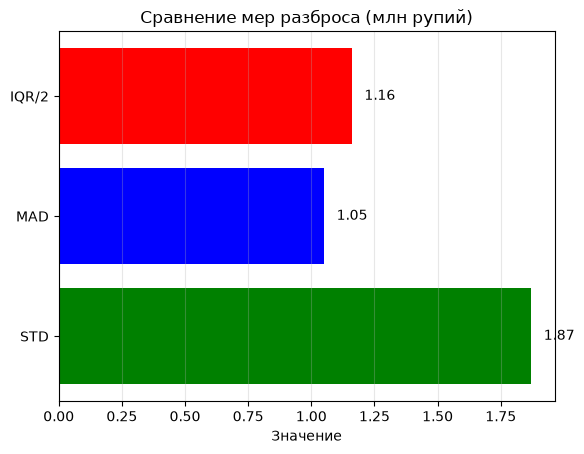

In [92]:
metrics = {'STD': 1.87, 'MAD': 1.05, 'IQR/2': 1.16}  # IQR/2 для сравнения с STD/MAD
plt.barh(list(metrics.keys()), list(metrics.values()), color=['g','b','r'])
plt.title('Сравнение мер разброса (млн рупий)')
plt.xlabel('Значение')
plt.grid(axis='x', alpha=0.3)
for i, v in enumerate(metrics.values()):
    plt.text(v+0.05, i, f"{v:.2f}", va='center')
plt.show()

## p-value - вероятность ошибки I рода
Что показывает: Если бы H1 не был лучше, то вероятность увидеть такие хорошие результаты (или еще лучше) была бы всего p%.

Как интерпретировать:

p < 0.05 → разница значимая

p ≥ 0.05 → разница не значимая

Важно: p-value ≠ вероятность того, что H₀ верна

## t-статистика - мера эффекта относительно variation
Что показывает: Отношение размера эффекта к variation данных

Формула: t = (разница средних) / (стандартная ошибка)

Интерпретация:

|t| > 2 → сильный эффект

1 < |t| < 2 → умеренный эффект

|t| < 1 → слабый эффект

In [93]:
дома_с_парковкой = data[data['parking'] > 0]['price']  # с парковкой
дома_без_парковки = data[data['parking'] == 0]['price']  # без парковки

print(f"Домов с парковкой: {len(дома_с_парковкой)}")
print(f"Домов без парковки: {len(дома_без_парковки)}")

Домов с парковкой: 246
Домов без парковки: 299


In [94]:
средняя_с_парковкой = дома_с_парковкой.mean()
средняя_без_парковки = дома_без_парковки.mean()

print(f"Средняя цена с парковкой: {средняя_с_парковкой:.0f} руб.")
print(f"Средняя цена без парковки: {средняя_без_парковки:.0f} руб.")
print(f"Разница: {средняя_с_парковкой - средняя_без_парковки:.0f} руб.")

Средняя цена с парковкой: 5533327 руб.
Средняя цена без парковки: 4136017 руб.
Разница: 1397310 руб.


In [95]:
from scipy import stats

_, p_нормальность_с = stats.shapiro(дома_с_парковкой)
_, p_нормальность_без = stats.shapiro(дома_без_парковки)

print(f"P-value нормальности (с парковкой): {p_нормальность_с:.3f}")
print(f"P-value нормальности (без парковки): {p_нормальность_без:.3f}")

if p_нормальность_с > 0.05 and p_нормальность_без > 0.05:
    print("Обе группы распределены нормально - используем t-тест")
else:
    print("Данные не нормальны - используем Манна-Уитни")

P-value нормальности (с парковкой): 0.000
P-value нормальности (без парковки): 0.000
Данные не нормальны - используем Манна-Уитни


In [96]:
_, p_дисперсии = stats.levene(дома_с_парковкой, дома_без_парковки)

print(f"P-value равенства дисперсий: {p_дисперсии:.3f}")

if p_дисперсии > 0.05:
    print("Дисперсии равны - используем t-тест с equal_var=True")
    equal_var = True
else:
    print("Дисперсии не равны - используем t-тест Уэлча")
    equal_var = False

P-value равенства дисперсий: 0.000
Дисперсии не равны - используем t-тест Уэлча


In [97]:
t_stat, p_value = stats.ttest_ind(дома_с_парковкой, дома_без_парковки, 
                                 equal_var=equal_var)

print(f"t-статистика: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

t-статистика: 8.973
p-value: 0.0000


In [98]:
разница = средняя_с_парковкой - средняя_без_парковки
n1, n2 = len(дома_с_парковкой), len(дома_без_парковки)
std1, std2 = дома_с_парковкой.std(), дома_без_парковки.std()

se = np.sqrt(std1**2/n1 + std2**2/n2)

ci_low = разница - 1.96 * se
ci_high = разница + 1.96 * se

print(f"Разница: {разница:.0f} руб.")
print(f"95% Доверительный интервал: [{ci_low:.0f}, {ci_high:.0f}] руб.")

Разница: 1397310 руб.
95% Доверительный интервал: [1092097, 1702524] руб.


In [99]:
pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1 + n2 - 2))
cohens_d = разница / pooled_std

print(f"Размер эффекта (Cohen's d): {cohens_d:.3f}")

if cohens_d < 0.2:
    print("Очень маленький эффект")
elif cohens_d < 0.5:
    print("Маленький эффект") 
elif cohens_d < 0.8:
    print("Средний эффект")
else:
    print("Большой эффект")

Размер эффекта (Cohen's d): 0.804
Большой эффект


In [100]:
print("\nВЫВОД:")
if p_value < 0.05:
    print("Статистически значимая разница!")
    if разница > 0:
        print(f"Дома с парковкой дороже на {разница:.0f} руб. ({разница/средняя_без_парковки*100:.1f}%)")
    else:
        print(f"Дома с парковкой дешевле на {-разница:.0f} руб.")
else:
    print(" Нет статистически значимой разницы")
    print("Не можем утверждать, что парковка влияет на цену")

print(f"Доверительный интервал: {ci_low:.0f} до {ci_high:.0f} руб.")


ВЫВОД:
Статистически значимая разница!
Дома с парковкой дороже на 1397310 руб. (33.8%)
Доверительный интервал: 1092097 до 1702524 руб.


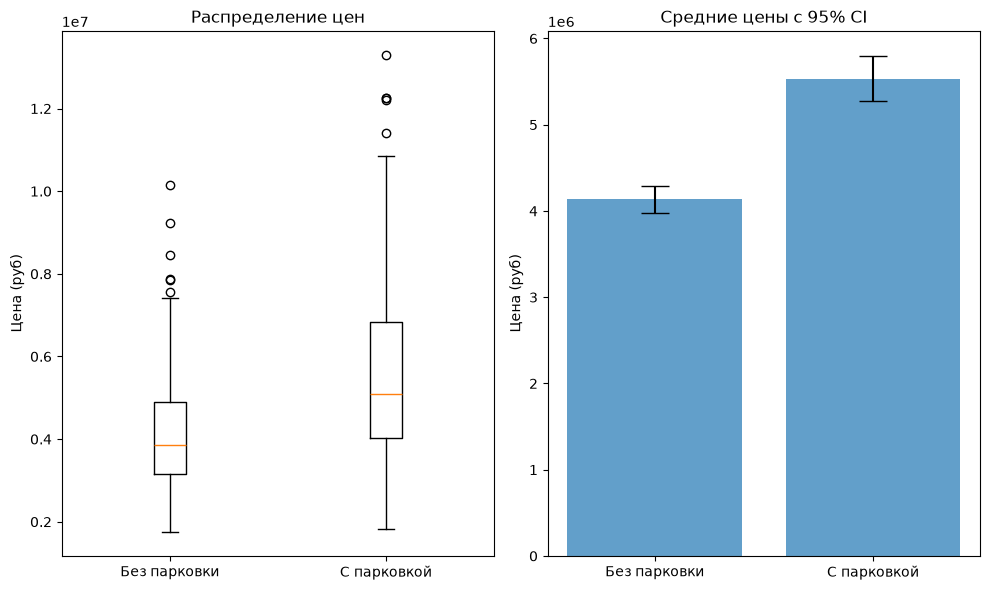

In [101]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.boxplot([дома_без_парковки, дома_с_парковкой])
plt.xticks([1, 2], ['Без парковки', 'С парковкой'])
plt.title('Распределение цен')
plt.ylabel('Цена (руб)')

plt.subplot(1, 2, 2)
plt.bar(['Без парковки', 'С парковкой'], 
        [средняя_без_парковки, средняя_с_парковкой],
        yerr=[1.96*дома_без_парковки.std()/np.sqrt(n2), 
              1.96*дома_с_парковкой.std()/np.sqrt(n1)],
        capsize=10, alpha=0.7)
plt.title('Средние цены с 95% CI')
plt.ylabel('Цена (руб)')

plt.tight_layout()
plt.show()

# ТЕСТЫ

## 1. Student's t-test
Условия: Нормальность + равные дисперсии

Пример: Сравнение цен домов с/без кондиционера

Код: stats.ttest_ind(group1, group2, equal_var=True)

## 2. Welch's t-test
Условия: Нормальность + НЕравные дисперсии

Пример: Сравнение зарплат в большой и маленькой компании

Код: stats.ttest_ind(group1, group2, equal_var=False)

## 3. Mann-Whitney U test
Условия: НЕНормальные данные или маленькая выборка

Пример: Сравнение оценок студентов из разных групп

Код: stats.mannwhitneyu(group1, group2)

## 4. ANOVA
Условия: 3+ группы, нормальность, равные дисперсии

Пример: Цены домов в 3 разных районах

Код: stats.f_oneway(group1, group2, group3)

## 5. Kruskal-Wallis test
Условия: 3+ группы, НЕНормальные данные

Пример: Удовлетворенность клиентов в 4 филиалах

Код: stats.kruskal(group1, group2, group3)

## 6. Paired t-test
Условия: Парные измерения, нормальность разниц

Пример: Вес до и после диеты

Код: stats.ttest_rel(before, after)

## 7. Z-test для пропорций
Условия: Большие выборки, бинарные данные

Пример: Конверсия на сайте до/после изменений

Код: proportions_ztest([success1, success2], [n1, n2])

## 8. Chi-square test
Условия: Категориальные данные

Пример: Связь между полом и выбором бренда

Код: stats.chi2_contingency(contingency_table)

# Тест на распределение 
## Тест Шапиро-Уилка (статистический тест)

Правило:

p > 0.05 → нормальное распределение

p ≤ 0.05 → не нормальное распределение

In [102]:
from scipy.stats import shapiro

stat, p_value = shapiro(data['price'])
print(f"P-value теста Шапиро-Уилка: {p_value:.4f}")

if p_value > 0.05:
    print(" Данные нормально распределены")
else:
    print("Данные НЕ нормально распределены")

P-value теста Шапиро-Уилка: 0.0000
Данные НЕ нормально распределены


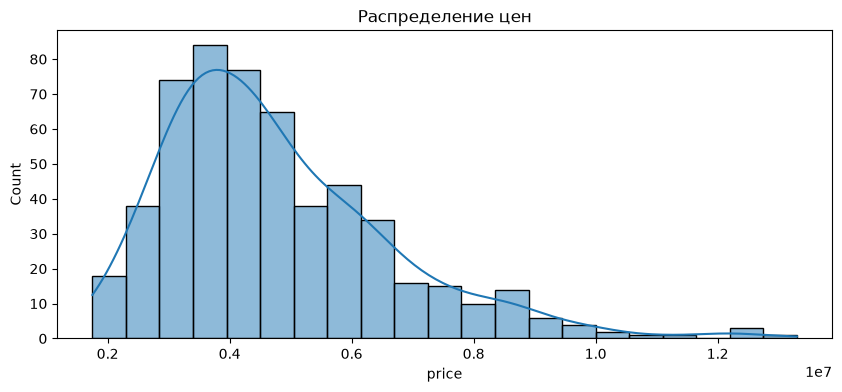

In [103]:
plt.figure(figsize=(10, 4))
sns.histplot(data['price'], kde=True) 
plt.title('Распределение цен')
plt.show()
